Integrantes:
- Vincenzo Palonsky | legajo: 1241/24
- Azul Soldani | legajo: 
- Francisco Amato | legajo: 

In [ ]:
import pandas as pd
import seaborn.objects as so
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, KMeans
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import root_mean_squared_error, r2_score
from statistics import mode

# Limpieza y Procesamiento de Datos

## Ejercicio 1

In [2]:
# Cargamos jugadores.csv en un DataFrame y vemos su contenido
df_jugadores = pd.read_csv("jugadores.csv")
df_jugadores

,player_id,seleccion,numero,posicion,jugador,fecha_nac,edad,caps,goles_seleccion,club,...,keeper_performance_cspct,keeper_penalty_kicks_pkatt,keeper_penalty_kicks_pka,keeper_penalty_kicks_pksv,keeper_penalty_kicks_pkm,keeper_penalty_kicks_savepct,keeper_playing_time_90s,nat3,valor_mercado_eur,posicion_tm
0,1,Czech Republic,1,GK,Matěj Kovář,2000-05-17,26,19,0,PSV Eindhoven,...,22.6,4.0,3.0,0.0,1.0,0.0,31.0,CZE,7000000.0,Goalkeeper
1,2,Czech Republic,2,DF,David Zima,2000-11-08,25,24,1,Slavia Prague,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CZE,4500000.0,Centre-Back
2,3,Czech Republic,3,DF,Tomáš Holeš,1993-03-31,33,40,2,Slavia Prague,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CZE,2200000.0,Centre-Back
3,4,Czech Republic,4,DF,Robin Hranáč,2000-01-29,26,13,1,TSG Hoffenheim,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CZE,5500000.0,Centre-Back
4,5,Czech Republic,5,DF,Vladimír Coufal,1992-08-22,33,61,2,TSG Hoffenheim,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CZE,7000000.0,Right-Back
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1240,1241,Panama,22,GK,Orlando Mosquera,1994-12-25,31,47,0,Al-Fayha,...,21.9,6.0,2.0,2.0,2.0,50.0,32.0,PAN,350000.0,Goalkeeper
1241,1242,Panama,23,DF,Michael Amir Murillo,1996-02-11,30,93,9,Beşiktaş,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAN,7000000.0,Right-Back
1242,1243,Panama,24,FW,Azarias Londoño,2001-06-21,24,10,0,Universidad Católica,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAN,175000.0,Centre-Forward
1243,1244,Panama,25,DF,Roderick Miller,1992-04-03,34,50,2,Turan Tovuz,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,175000.0,Centre-Back


## Ejercicio 2

### Ítem a)

Veamos cuántos jugadores hay por selección

In [3]:
selecciones = df_jugadores.groupby("seleccion")
selecciones.size().unique()

array([26, 25])

Tenemos selecciones con 25 y 26 jugadores. Cuáles son aquellas que tienen 25?

In [4]:
selecciones.size()[selecciones.size() == 25]

seleccion
Austria    25
Canada     25
Jordan     25
dtype: int64

Todas las selecciones tienen 26 jugadores, excepto Austria, Canadá y Jordania que tienen 25

### Ítem b)

In [5]:
cantidad_jugadores_clubes = df_jugadores.groupby("club").size()
cantidad_jugadores_clubes[cantidad_jugadores_clubes>=10].sort_values()

club
Fenerbahçe             10
Milan                  10
Real Madrid            10
PSV Eindhoven          10
Slavia Prague          10
Galatasaray            11
Liverpool              11
Borussia Dortmund      11
Atlético Madrid        12
Manchester United      12
Crystal Palace         12
Al-Hilal               12
Barcelona              15
Paris Saint-Germain    16
Arsenal                16
Bayern Munich          18
Manchester City        19
dtype: int64

Manchester City, Bayern Munich y Arsenal son los tres clubes con más jugadores convocados al mundial

### Ítem c)

In [6]:
# Definimos una función lambda que devuelve el rango etario segúna la edad del jugador
rango_etario = lambda edad : "A" if edad < 24 else ("B" if edad <= 30 else "C")

# Agregamos la columna rango_etario usando la lambda en cada jugador
df_jugadores["rango_etario"] = [rango_etario(edad) for edad in df_jugadores["edad"]]
df_jugadores.head()

,player_id,seleccion,numero,posicion,jugador,fecha_nac,edad,caps,goles_seleccion,club,...,keeper_penalty_kicks_pkatt,keeper_penalty_kicks_pka,keeper_penalty_kicks_pksv,keeper_penalty_kicks_pkm,keeper_penalty_kicks_savepct,keeper_playing_time_90s,nat3,valor_mercado_eur,posicion_tm,rango_etario
0,1,Czech Republic,1,GK,Matěj Kovář,2000-05-17,26,19,0,PSV Eindhoven,...,4.0,3.0,0.0,1.0,0.0,31.0,CZE,7000000.0,Goalkeeper,B
1,2,Czech Republic,2,DF,David Zima,2000-11-08,25,24,1,Slavia Prague,...,NaN,NaN,NaN,NaN,NaN,NaN,CZE,4500000.0,Centre-Back,B
2,3,Czech Republic,3,DF,Tomáš Holeš,1993-03-31,33,40,2,Slavia Prague,...,NaN,NaN,NaN,NaN,NaN,NaN,CZE,2200000.0,Centre-Back,C
3,4,Czech Republic,4,DF,Robin Hranáč,2000-01-29,26,13,1,TSG Hoffenheim,...,NaN,NaN,NaN,NaN,NaN,NaN,CZE,5500000.0,Centre-Back,B
4,5,Czech Republic,5,DF,Vladimír Coufal,1992-08-22,33,61,2,TSG Hoffenheim,...,NaN,NaN,NaN,NaN,NaN,NaN,CZE,7000000.0,Right-Back,C


In [7]:
# Las cinco selecciones con mayor ranking FIFA actual
top_cinco_ranking_fifa = ["Argentina", "Francia", "España", "Inglaterra", "Brasil"]

# Nos que damos con los jugadores de esas selecciones
df_top_cinco = df_jugadores[df_jugadores["seleccion"].isin(top_cinco_ranking_fifa)]

# Contamos sus rangos etarios
df_top_cinco.groupby("rango_etario").size().sort_values(ascending=False)

rango_etario
B    15
C     8
A     3
dtype: int64

El rango etario dominante en las primeras cinco selecciones del ranking FIFA es entre 24 y 30 años

## Ejercicio 3

In [8]:
variables = ["standard_playing_time_mp", "shooting_90s", "misc_performance_fls", "playing_time_starts_starts"]

# Nos quedamos con las variables a analizar
df_variables = df_jugadores[variables]

# Vemos el porcentaje de cobertura de cada variable
df_variables.notna().sum()/len(df_jugadores) * 100

standard_playing_time_mp      73.975904
shooting_90s                  74.056225
misc_performance_fls          71.405622
playing_time_starts_starts    38.232932
dtype: float64

Como la variable del grupo playing_time_ no llega al 40% de cobertura, eliminamos todas las variables del grupo

In [9]:
# Eliminamos las columnas que arrancan con "playing_time_"
variables_playing_time = [col for col in df_jugadores.columns if col.startswith("playing_time_")]
df_jugadores.drop(columns=variables_playing_time, inplace=True)

# Vemos la cantidad de columnas que nos quedan luego de eliminar las variables de playing_time
df_jugadores.columns.size

82

## Ejercicio 4

Las variables que estén en NAN las podemos poner en 0, ya que se basan en tiros y, si el jugador no realizó ninguno, cualquier ratio debería dar 0

In [10]:
# Nos quedamos con las variables de shooting
variables_shooting = [col for col in df_jugadores.columns if col.startswith("shooting_")]

# Reemplazamos los valores faltantes por 0
df_jugadores.fillna({col : 0 for col in variables_shooting}, inplace=True)

# Verificamos que los valores faltantes hayan sido reemplazados
df_jugadores[variables_shooting].isna().sum()

shooting_90s                    0
shooting_standard_gls           0
shooting_standard_sh            0
shooting_standard_sot           0
shooting_standard_sotpct        0
shooting_standard_sh_per_90     0
shooting_standard_sot_per_90    0
shooting_standard_g_per_sh      0
shooting_standard_g_per_sot     0
shooting_standard_pk            0
shooting_standard_pkatt         0
dtype: int64

## Ejercicio 5

La baja cobertura de las variables keeper_ se debe a que solo aplica a aquellos jugadores que ocupen esta posición. Esto se puede arreglar reemplazando los NA por 0, ya que como el resto de jugadores no son arqueros no van a aplicar a estas estadísticas.

In [11]:
# Nos quedamos con las variables de keeper
variables_keeper = [col for col in df_jugadores.columns if col.startswith("keeper_")]

# Reemplazamos los valores faltantes por 0
df_jugadores.fillna({col: 0 for col in variables_keeper}, inplace=True)

# Verificamos que los valores faltantes hayan sido reemplazados
df_jugadores[variables_keeper].isna().sum()

keeper_playing_time_mp          0
keeper_playing_time_starts      0
keeper_playing_time_min         0
keeper_90s                      0
keeper_performance_ga           0
keeper_performance_ga90         0
keeper_performance_sota         0
keeper_performance_saves        0
keeper_performance_savepct      0
keeper_performance_w            0
keeper_performance_d            0
keeper_performance_l            0
keeper_performance_cs           0
keeper_performance_cspct        0
keeper_penalty_kicks_pkatt      0
keeper_penalty_kicks_pka        0
keeper_penalty_kicks_pksv       0
keeper_penalty_kicks_pkm        0
keeper_penalty_kicks_savepct    0
keeper_playing_time_90s         0
dtype: int64

## Ejercicio 6

Veamos primero cuál es el porcentaje de cobertura de las variables que todavía no limpiamos y cuántos valores faltantes hay por filas

In [12]:
# Porcentaje de valores no faltantes por variable
porcentajes = (df_jugadores.notna().sum() / len(df_jugadores) * 100).sort_values()

# Vemos cuáles no cubren el 100%
pd.DataFrame({"variable": porcentajes[porcentajes < 100].index, "porcentaje_cobertura": porcentajes[porcentajes < 100].values})

,variable,porcentaje_cobertura
0,misc_performance_pkwon,0.000000
1,misc_performance_pkcon,0.000000
2,misc_performance_int,71.405622
3,misc_performance_crs,71.405622
4,misc_performance_tklw,71.405622
5,misc_performance_fld,71.405622
6,misc_performance_off,71.405622
7,misc_performance_fls,71.405622
8,nation_fbref,73.895582
9,nat3,73.895582


In [13]:
# Sumamos la cantidad de valores faltantes por fila
nulos_por_fila = df_jugadores.isna().sum(axis=1)

# Nos quedamos con las filas que tienen al menos un valor faltante
filas_con_nulos = nulos_por_fila[nulos_por_fila > 0].value_counts().sort_index()

# Visualizamos
pd.DataFrame({"cantidad_faltantes": filas_con_nulos.index, "cantidad_filas": filas_con_nulos.values})

,cantidad_faltantes,cantidad_filas
0,2,873
1,3,8
2,4,7
3,8,33
4,21,1
5,32,1
6,34,294
7,35,4
8,36,24


Eliminamos las variables "misc_performance_pkwon" y "misc_performance_pkcon" que directamente no tienen ningún valor no nulo

In [14]:
# Eliminamos las variables misc_performance_pkwon y misc_performance_pkcon, ya que tienen 0% de cobertura, y creamos el nuevo DataFrame
df_jugadores_limpia = df_jugadores.drop(columns=["misc_performance_pkwon", "misc_performance_pkcon"])

Eliminemos las variables de fbref y transfermarket, pues no las necesitamos, y reemplacemos los NA de valor en el mercado europeo por 0

In [ ]:
# Eliminamos las columnas de fbref y transfermarket
df_jugadores_limpia.drop(columns=["posicion_tm", "club_fbref", "player_fbref", "nat3", "nation_fbref"], inplace=True)

# Reemplazamos los valores faltantes en la columna "valor_mercado_eur" por 0]
df_jugadores_limpia.fillna({"valor_mercado_eur" : 0}, inplace=True)

75

Finalmente eliminamos los jugadores que le queden valores nulos

In [16]:
# Eliminamos filas con al menos un valor faltante y reseteamos el índice del DataFrame
df_jugadores_limpia.drop(df_jugadores_limpia[df_jugadores_limpia.isna().sum(axis=1)>0].index, inplace=True)
df_jugadores_limpia.reset_index(drop=True, inplace=True)

In [17]:
print("Cantidad de jugadores: " + str(len(df_jugadores_limpia)))
print("Cantidad de variables numericas: " + str(len(df_jugadores_limpia.select_dtypes(include='number').columns)))

Cantidad de jugadores: 888
Cantidad de variables numericas: 65


Finalmente nos quedamos con 888 jugadores y 65 variables numéricas

## Ejercicio 7

Primero eliminamos las selecciones con menos de 5 jugadores convocados

In [18]:
# Obtenemos las selecciones con menos de 5 jugadores
selecciones_a_eliminar = df_jugadores_limpia["seleccion"].value_counts()[df_jugadores_limpia["seleccion"].value_counts()<=4].index

# Mostramos cuáles se eliminarán
print(selecciones_a_eliminar)

# Obtenemos los jugadores a eliminar, pertenecientes a esas selecciones
jugadores_a_eliminar = df_jugadores_limpia[df_jugadores_limpia["seleccion"].isin(selecciones_a_eliminar)].index

# Eliminamos los jugadores y reseteamos el índice del DataFrame
df_jugadores_limpia.drop(index=jugadores_a_eliminar, inplace=True)
df_jugadores_limpia.reset_index(drop=True, inplace=True)

Index(['Egypt', 'Iran', 'Jordan', 'Uzbekistan'], dtype='str', name='seleccion')


Para hacer el promedio de las variables numéricas vamos a diferenciar entre las que corresponden a los arqueros y el resto. Entonces, separamos primero en un DataFrame de arqueros, junto con sus variables, y en otro de jugadores, con el resto de las columnas. Así logramos que el promedio de las variables de los arqueros no quede sesgado por la cantidad de arqueros en cada selección.

In [19]:
# Columnas que empiezan con "keeper_"
variables_keeper = [col for col in df_jugadores_limpia.columns if col.startswith("keeper_")]

# Filas de arqueros (GK) + variables keeper_
df_keeper = df_jugadores_limpia.loc[
    df_jugadores_limpia["posicion"] == "GK",
    ["seleccion"] + variables_keeper
].copy()

# Resto de las columnas
otras_cols = [col for col in df_jugadores_limpia.columns if col not in variables_keeper]

# Resto de los jugadores + resto de las variables
df_jugadores = df_jugadores_limpia.loc[
    df_jugadores_limpia["posicion"] != "GK",
    otras_cols
].copy()
selecciones = df_jugadores["seleccion"]
df_jugadores = df_jugadores.select_dtypes(include='number').drop(columns=["player_id", "numero"])
df_jugadores["seleccion"] = selecciones

# Tomamos promedio de las variables por selección
df_keeper_promedio = df_keeper.groupby("seleccion").mean().reset_index()
df_jugadores_promedio = df_jugadores.groupby("seleccion").mean().reset_index()

# Unimos los DataFrames de jugadores y arqueros por selección, rellenando con 0 los valores faltantes
df_selecciones = pd.concat([df_jugadores_promedio.set_index("seleccion"), df_keeper_promedio.set_index("seleccion")], axis=1).reset_index().fillna(0)
print("Cantidad de selecciones: " + str(len(df_selecciones)))
print("Cantidad de variables numericas: " + str(len(df_selecciones.select_dtypes(include='number').columns)))
df_selecciones.head()

Cantidad de selecciones: 43
Cantidad de variables numericas: 63


,seleccion,edad,caps,goles_seleccion,standard_playing_time_mp,standard_playing_time_starts,standard_playing_time_min,standard_playing_time_90s,standard_performance_gls,standard_performance_ast,...,keeper_performance_d,keeper_performance_l,keeper_performance_cs,keeper_performance_cspct,keeper_penalty_kicks_pkatt,keeper_penalty_kicks_pka,keeper_penalty_kicks_pksv,keeper_penalty_kicks_pkm,keeper_penalty_kicks_savepct,keeper_playing_time_90s
0,Algeria,26.875000,41.375000,6.500000,24.937500,20.312500,1780.875000,19.768750,3.812500,3.062500,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Argentina,28.523810,54.476190,10.333333,24.571429,20.047619,1770.000000,19.676190,4.476190,3.190476,...,3.666667,7.666667,6.333333,30.033333,3.333333,2.666667,0.333333,0.333333,33.333333,0.000000
2,Australia,26.470588,23.941176,2.470588,20.764706,16.294118,1470.764706,16.335294,1.294118,1.058824,...,8.000000,12.333333,8.666667,31.100000,2.000000,1.333333,0.666667,0.000000,41.666667,16.666667
3,Austria,27.850000,40.600000,5.050000,25.250000,19.300000,1707.550000,18.970000,2.250000,2.300000,...,6.000000,8.666667,8.666667,35.133333,3.000000,2.333333,0.000000,0.666667,0.000000,26.866667
4,Belgium,27.304348,41.565217,9.086957,27.652174,22.826087,2021.608696,22.456522,2.826087,2.956522,...,7.000000,6.666667,9.666667,29.933333,4.333333,4.000000,0.333333,0.000000,6.666667,0.000000


Obtuvimos finalmente un DataFrame con 43 selecciones y 63 variables numéricas

# Análisis exploratorio

Se quiere analizar diferentes aspectos de las selecciones en función de su _tipo de juego_ (**ofensivo** o **defensivo**).

Para esto hay que definir cómo medir cuantitativamente la ofensiva y defensiva de un equipo: La idea es determinar las variables que describen la ofensiva y defensiva, luego escalarlas para estandarizar las medidas (que significan diferentes cosas y se miden en diferentes escalas y proporciones) y hacer un promedio ponderado de los puntajes estandarizados para crear un **indice de ofesiva** y un **indice de defensiva**.

Variables que describen un comportamiento OFENSIVO:
- **shooting_standard_sot_per_90**: Tiros al arco en un partido que llegan a generar presión sobre el arquero rival (si no ataja es gol). Medición de la peligrosidad de los ataques al arco.
- **shooting_standard_sh_per_90**: Tiros en un partido con intención de hacer gol pero que no generan presión sobre el arquero (sea porque un defensor bloquea el tiro, o porque se va afuera). Medición de volumen de ataques al arco.
- **misc_performance_crs / misc_90s**: Medición de centros en un partido que indican juegos ofensivos por las bandas que llegan al área via centro.
- **misc_performance_fld / misc_90s**: Faltas recibidas en un partido que indican la presión que ejerce el equipo de manera que para frenarlos se llegan a cometer faltas.
- **misc_performance_off / misc_90s**: Faltas por _fuera de juego_ (offside) en un partido que indica un comportamiento de carrera a fondo del equipo para poder llegar al área rival.

Variables que describen un comportamiento DEFENSIVO:
- **misc_performance_int / misc_90s**: Intercepciones de la pelota en un partido para su recuperación.
- **misc_performance_tklw / misc_90s**: Entradas ganadas en un partido para la recuperación de la pelota.
- **misc_performance_fls / misc_90s**: Faltas cometidas en un partido como medición del último recurso para frenar la jugada de ataque.


In [20]:
# Creo un df con las variables que necesito a partir de df_selecciones
df_ofensiva_defensiva = df_selecciones[[
    "seleccion",
    "shooting_standard_sot_per_90",
    "shooting_standard_sh_per_90",
    "misc_90s",
    "misc_performance_crs",
    "misc_performance_fld",
    "misc_performance_off",
    "misc_performance_int",
    "misc_performance_tklw",
    "misc_performance_fls"]].set_index("seleccion")

# Proceso las variables de misc_performance para que sean por 90 minutos (por partido)
variables_misc = [col for col in df_ofensiva_defensiva.columns if col.startswith("misc_performance")]
df_ofensiva_defensiva[variables_misc] = df_ofensiva_defensiva[variables_misc].div(df_ofensiva_defensiva["misc_90s"], axis=0)
df_ofensiva_defensiva = df_ofensiva_defensiva.rename(columns={col: col + "_per_90" for col in variables_misc})
df_ofensiva_defensiva.drop(columns="misc_90s", inplace=True) # elimino del df la columna misc_90s que ya usé

# Estandarizo las variables
df_ofensiva_defensiva = StandardScaler().set_output(transform="pandas").fit_transform(df_ofensiva_defensiva)

# Creo los indices de ofensiva y defensiva haciendo un promedio ponderado de las variables estandarizadas
df_ofensiva_defensiva["indice_ofensiva"] = 0.2 * df_ofensiva_defensiva["shooting_standard_sot_per_90"] +\
                                            0.2 * df_ofensiva_defensiva["shooting_standard_sh_per_90"] +\
                                            0.2 * df_ofensiva_defensiva["misc_performance_crs_per_90"] +\
                                            0.2 * df_ofensiva_defensiva["misc_performance_fld_per_90"] +\
                                            0.2 * df_ofensiva_defensiva["misc_performance_off_per_90"]

df_ofensiva_defensiva["indice_defensiva"] = 0.34 * df_ofensiva_defensiva["misc_performance_int_per_90"] +\
                                            0.33 * df_ofensiva_defensiva["misc_performance_tklw_per_90"] +\
                                            0.33 * df_ofensiva_defensiva["misc_performance_fls_per_90"]


df_ofensiva_defensiva.head()

,shooting_standard_sot_per_90,shooting_standard_sh_per_90,misc_performance_crs_per_90,misc_performance_fld_per_90,misc_performance_off_per_90,misc_performance_int_per_90,misc_performance_tklw_per_90,misc_performance_fls_per_90,indice_ofensiva,indice_defensiva
seleccion,,,,,,,,,,
Algeria,-0.026854,0.259197,1.926545,-0.565446,0.136141,0.135563,-0.376433,-0.955918,0.345917,-0.393585
Argentina,0.719203,0.540579,0.398625,1.081968,-0.808186,-0.110439,0.200930,-0.444184,0.386438,-0.117823
Australia,-0.766188,-0.844762,0.113622,0.439198,-1.514485,1.486706,1.775441,-0.260987,-0.514523,1.005250
Austria,-1.346255,-1.367720,-0.781389,-0.604989,-1.359715,1.212130,1.175000,-1.044508,-1.092013,0.455186
Belgium,-0.019261,-0.117312,0.044885,-0.177569,-0.998890,0.172337,0.075542,-1.057162,-0.253629,-0.265340


Con los indices de ofensiva y defensiva ya calculados por selección, ahora se suman otros datos para analizar en base a estos indices.

In [21]:
# Primero los datos de confederación a la cual pertenece cada selección, tomados de df_jugadores_limpia
df_ofensiva_defensiva["confederacion"] = df_jugadores_limpia.groupby("seleccion")["confederacion"].first()

# Ahora los datos de edad promedio, valor de mercado y la cantidad de mundiales promedio de cada jugador, tomados de df_selecciones
df_ofensiva_defensiva[["valor_mercado_eur", "edad", "caps"]] = df_selecciones.set_index("seleccion")[["valor_mercado_eur",
                                                                                                        "edad",
                                                                                                        "caps"]]

# Mejoro la visualización del valor de mercado para que sea mas legible
df_ofensiva_defensiva["valor_mercado_eur"] = df_ofensiva_defensiva["valor_mercado_eur"] / 1_000_000
df_ofensiva_defensiva = df_ofensiva_defensiva.rename(columns={"valor_mercado_eur": "valor_mercado_mill_eur"})

In [22]:
df_ofensiva_defensiva[["confederacion","edad","caps","indice_ofensiva","indice_defensiva","valor_mercado_mill_eur" ]].head()

,confederacion,edad,caps,indice_ofensiva,indice_defensiva,valor_mercado_mill_eur
seleccion,,,,,,
Algeria,CAF,26.875000,41.375000,0.345917,-0.393585,10.725000
Argentina,CONMEBOL,28.523810,54.476190,0.386438,-0.117823,32.285714
Australia,AFC,26.470588,23.941176,-0.514523,1.005250,2.085294
Austria,UEFA,27.850000,40.600000,-1.092013,0.455186,13.405000
Belgium,UEFA,27.304348,41.565217,-0.253629,-0.265340,20.913043


#### ¿Como es el estilo de juego de las selecciones según la confederación de futbol a la que pertenecen?

**Conclusiones:**

Si bien en la dispersión de selecciones se pueden identificar outliers, también se puede ver como la gran mayoria de las selecciones participantes del mundial 2026 tienen una eficacia en ataque y defensa cercanas al promedio (coordenada (0,0)). Si se hace un estudio por confederación se puede ver que:

- CONMEBOL: Sus selecciones destacan más por su defensa que por la ofensiva.
- UEFA: Al reves que con la CONMEBOL, las selecciones de esta federación son mas eficaces en ataque que en defensa, siendo la defensa en promedio peor que las defensas del resto de selecciones.
- CAF y AFC: Son las confederaciones que mayor diferencia presentan entre sus selecciones, pudiendose observar en el gráfico de dispersión una gran variedad de eficacias y deficiencias tanto en ataque como en defensa. Tienen selecciones con valores de indices muy extremos, por lo que los promedios de los indices pueden estár distorcionados.
- CONCAF: Las selecciones de esta confederación presentan una mejor eficacia en defensa que el promedio de todas las selecciones, pero no tan superior como lo es la defensa en las selecciones de la CONMEBOL. Por otro lado, no destácan en ataque, siendo su eficacia peor que el promedio.
- OFC: Se cuentan con datos de una única selección de esta confederación, por lo que no es representativo de todas las selecciones que hay en la misma. Lo que si se puede decir es que Nueva Zelanda presenta una muy buena eficacia en su defensa, sin embargo su ofensiva es peor que el promedio de todas las selecciones.

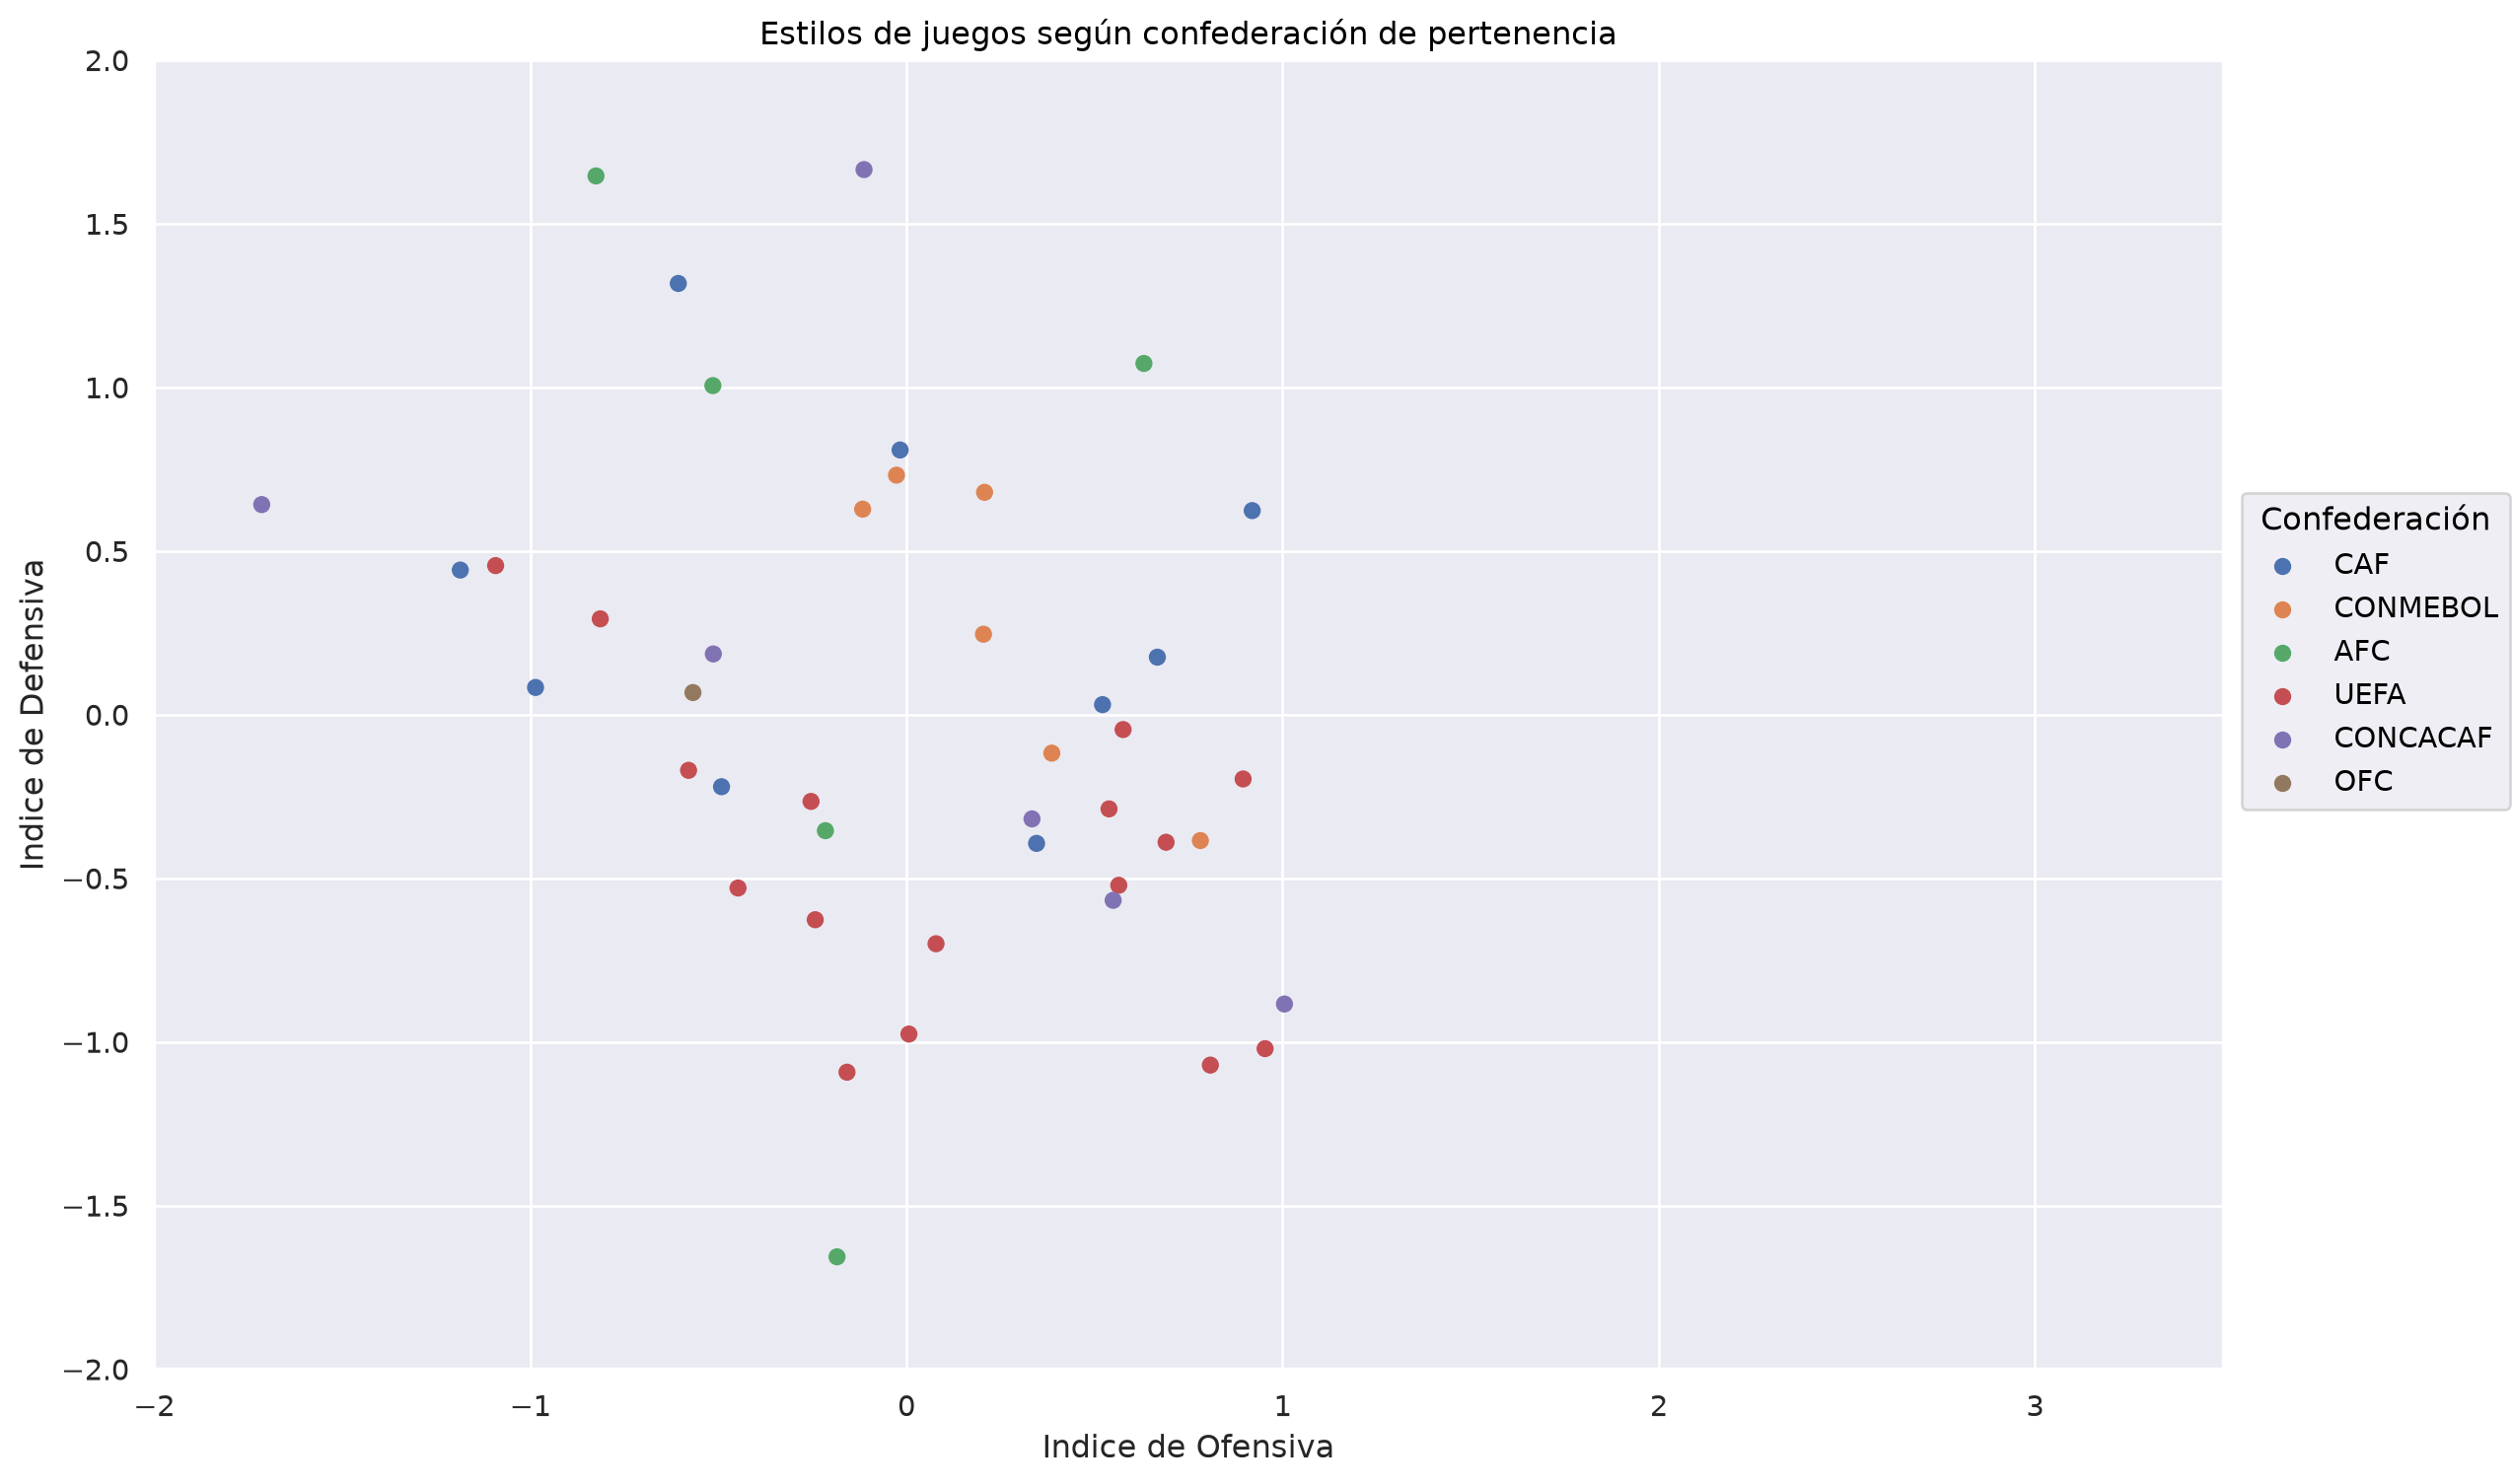

In [23]:
(
        so.Plot(data = df_ofensiva_defensiva,
                x = "indice_ofensiva",
                y = "indice_defensiva",
                color="confederacion",)
        .add(so.Dot())
        .limit(x=(-2, 3.5), y=(-2, 2))
        .layout(size=(12,8))
        .label(
                x="Indice de Ofensiva",
                y="Indice de Defensiva",
                title="Estilos de juegos según confederación de pertenencia",
                color="Confederación"
        )
)

In [24]:
# Promedios de indices según confederación y tamaño de la muestr (selecciones
df_confederaciones = (
    df_ofensiva_defensiva
    .groupby("confederacion")
    .agg(
        indice_ofensiva  = ("indice_ofensiva",  "mean"),
        indice_defensiva = ("indice_defensiva", "mean"),
        cant_selecciones    = ("indice_ofensiva",  "count")
    )
    .round(2)
)

df_confederaciones

,indice_ofensiva,indice_defensiva,cant_selecciones
confederacion,,,
AFC,-0.22,0.34,5
CAF,-0.09,0.32,9
CONCACAF,-0.08,0.12,6
CONMEBOL,0.24,0.30,6
OFC,-0.57,0.07,1
UEFA,0.10,-0.45,16


In [25]:
df_ofensiva_defensiva[df_ofensiva_defensiva["confederacion"] == "OFC"]

,shooting_standard_sot_per_90,shooting_standard_sh_per_90,misc_performance_crs_per_90,misc_performance_fld_per_90,misc_performance_off_per_90,misc_performance_int_per_90,misc_performance_tklw_per_90,misc_performance_fls_per_90,indice_ofensiva,indice_defensiva,confederacion,valor_mercado_mill_eur,edad,caps
seleccion,,,,,,,,,,,,,,
New Zealand,-0.204502,-0.492829,0.50898,-1.27513,-1.374402,1.27664,0.473018,-1.584304,-0.567577,0.067333,OFC,0.945,28.8,33.266667


In [26]:
df_ofensiva_defensiva[df_ofensiva_defensiva["confederacion"] == "AFC"]

,shooting_standard_sot_per_90,shooting_standard_sh_per_90,misc_performance_crs_per_90,misc_performance_fld_per_90,misc_performance_off_per_90,misc_performance_int_per_90,misc_performance_tklw_per_90,misc_performance_fls_per_90,indice_ofensiva,indice_defensiva,confederacion,valor_mercado_mill_eur,edad,caps
seleccion,,,,,,,,,,,,,,
Australia,-0.766188,-0.844762,0.113622,0.439198,-1.514485,1.486706,1.775441,-0.260987,-0.514523,1.005250,AFC,2.085294,26.470588,23.941176
Iraq,-0.021220,-0.568515,1.892683,1.782404,0.071082,0.509657,0.149556,2.576816,0.631287,1.072986,AFC,1.106250,23.625000,23.250000
Japan,0.150862,-0.414384,-0.558642,-0.901469,0.646808,0.500781,-0.633703,-0.957406,-0.215365,-0.354800,AFC,9.845455,27.545455,35.954545
Saudi Arabia,-0.993428,-1.370387,-0.261260,-1.429348,-0.071969,1.578655,2.364133,0.997134,-0.825278,1.645961,AFC,1.271429,27.523810,35.952381
South Korea,0.613216,-0.004909,-0.743144,-1.548040,0.760207,-1.329443,-2.483548,-1.167609,-0.184534,-1.656893,AFC,12.511538,27.846154,51.384615


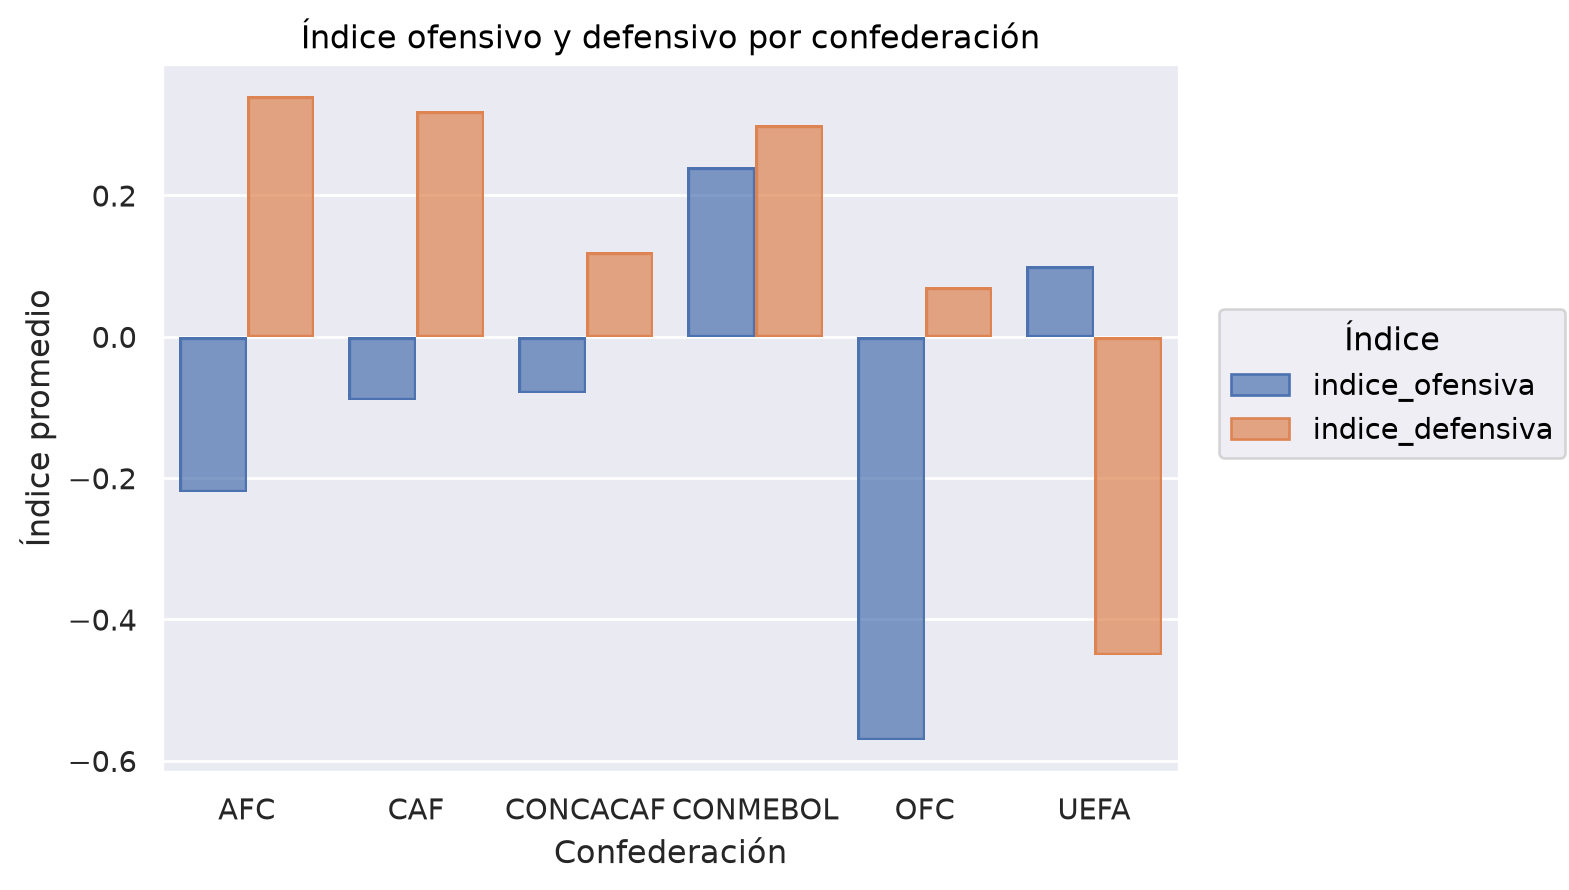

In [27]:
df_confederaciones_plot = df_confederaciones.reset_index().melt(
    id_vars="confederacion",
    value_vars=["indice_ofensiva", "indice_defensiva"],
    var_name="indice",
    value_name="valor"
)

(
    so.Plot(data=df_confederaciones_plot, x="confederacion", y="valor", color="indice")
    .add(so.Bar(), so.Dodge())
    .label(
        x="Confederación",
        y="Índice promedio",
        title="Índice ofensivo y defensivo por confederación",
        color="Índice"
    )
)

# PCA y Clustering

## Ejercicio 1

Escalamos con MinMax para que nos queden datos positivos y poder interpretar mejor a qué le dan peso los coeficientes de las componentes principales

In [28]:
# Nos quedamos con las variables numéricas y las escalamos
df_selecciones_numerica = df_selecciones.drop(columns=["seleccion"])
df_selecciones_numerica_escalada = MinMaxScaler().set_output(transform="pandas").fit_transform(df_selecciones_numerica)

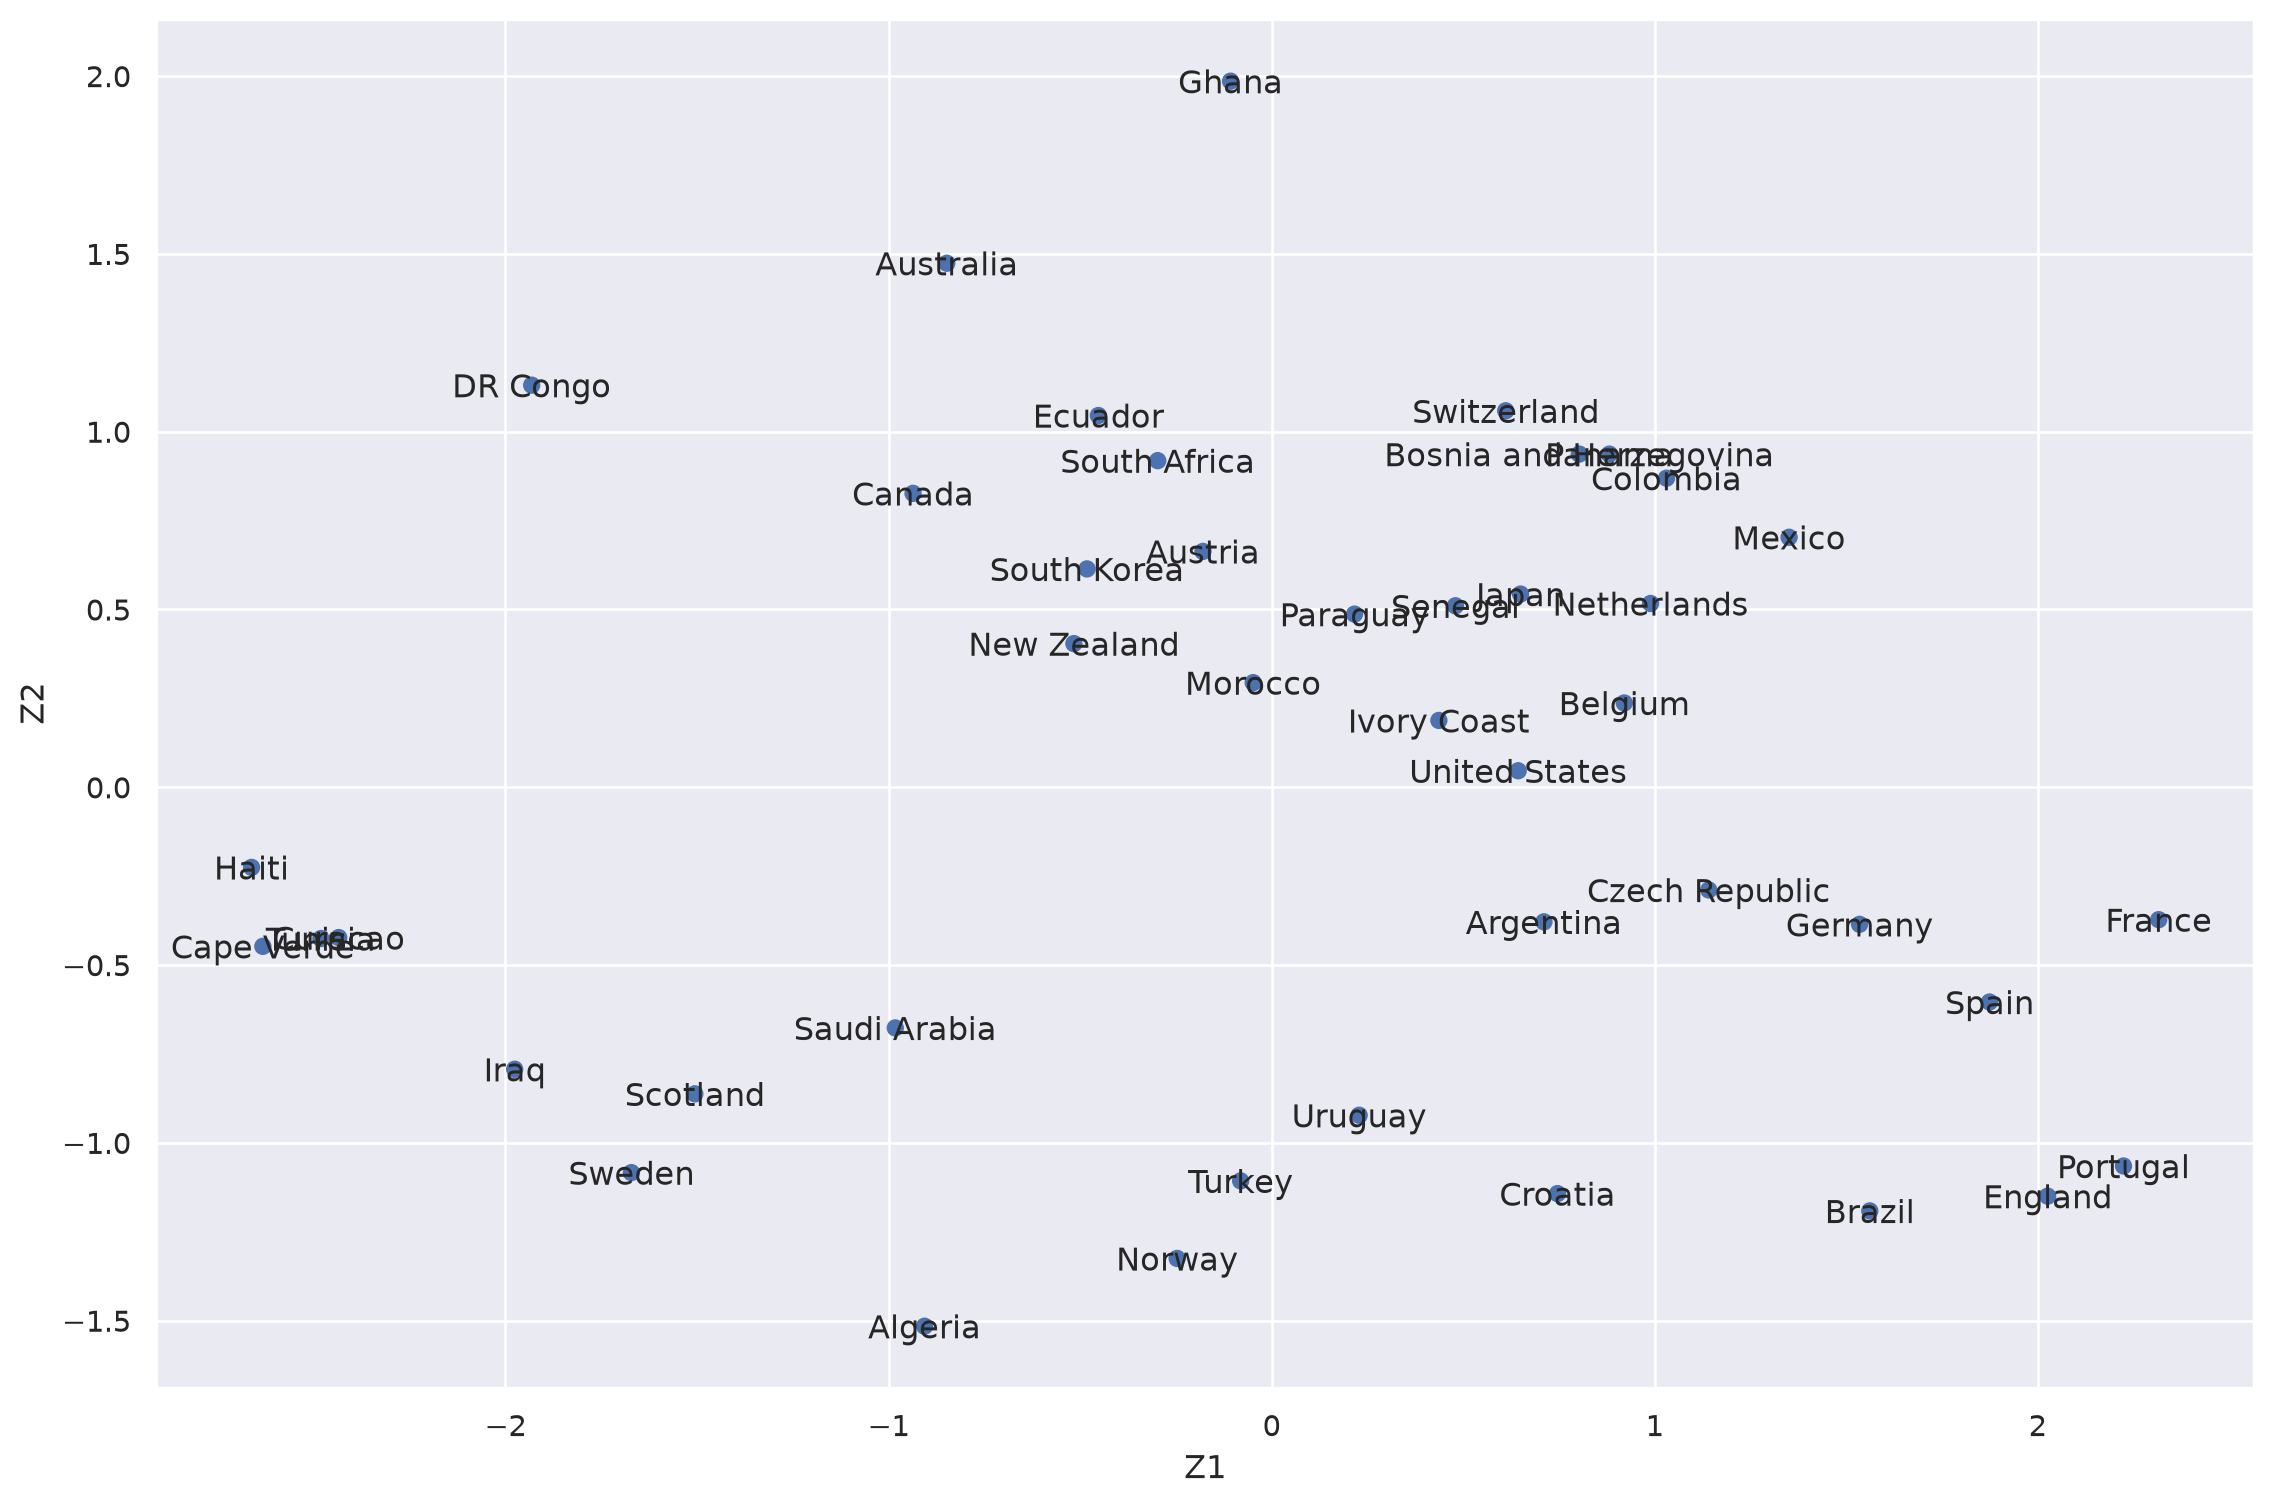

In [29]:
# Vamos a utilizar dos componentes principales
n_comps = 2
pca = PCA(n_components=n_comps)

# Aplicamos PCA a las variables numéricas escaladas y creamos un DataFrame con los resultados
Z = pd.DataFrame(pca.fit_transform(df_selecciones_numerica_escalada))
Z.columns = ["Z" + str(i) for i in range(1,n_comps+1)]

# Graficamos la segunda componente principal (Z2) contra la primera (Z1) y agregamos los nombres de las selecciones
(
    so.Plot(data = Z, x="Z1", y="Z2", text=df_selecciones["seleccion"])
    .add(so.Dot())
    .add(so.Text())
    .layout(size=(12,8))
)

Se puede ver que hay una cierta división de las selecciones, con una gran concentración cerca del centro y luego dos grupos abajo derecha y abajo izquierda

## Ejercicio 2

Analicemos a qué variables le dan peso las primeras dos componentes principales

In [30]:
z1 = pd.Series(pca.components_[0])
direcciones_z1 = pd.DataFrame({
	"valores_negativos": z1.sort_values().head(10).reset_index(drop=True),
	"columnas_negativas": [df_selecciones_numerica.columns[i] for i in z1.sort_values().head(10).index],
	"valores_positivos": z1.sort_values(ascending=False).head(10).reset_index(drop=True),
	"columnas_positivas": [df_selecciones_numerica.columns[i] for i in z1.sort_values(ascending=False).head(10).index]
})
direcciones_z1

,valores_negativos,columnas_negativas,valores_positivos,columnas_positivas
0,-0.042812,misc_performance_2crdy,0.206923,keeper_playing_time_starts
1,-0.022436,standard_performance_crdr,0.205584,keeper_playing_time_mp
2,-0.022436,misc_performance_crdr,0.205430,keeper_playing_time_min
3,0.017020,misc_performance_og,0.169008,keeper_performance_w
4,0.018859,edad,0.161065,keeper_penalty_kicks_pka
5,0.033811,shooting_standard_g_per_sh,0.156981,shooting_standard_sot
6,0.050872,shooting_standard_g_per_sot,0.153941,standard_performance_g-pk
7,0.053631,caps,0.153659,standard_performance_gls
8,0.057884,keeper_penalty_kicks_pkm,0.153659,shooting_standard_gls
9,0.058437,misc_performance_int,0.153621,standard_per_90_minutes_gpa


z1 le da importancia tanto a las variables de los arqueros (como su tiempo de juego, penales recibidos y victorias) como a los goles de la selección

In [31]:
z2 = pd.Series(pca.components_[1])
direcciones_z2 = pd.DataFrame({
	"valores_negativos": z2.sort_values().head(10).reset_index(drop=True),
	"columnas_negativas": [df_selecciones_numerica.columns[i] for i in z2.sort_values().head(10).index],
	"valores_positivos": z2.sort_values(ascending=False).head(10).reset_index(drop=True),
	"columnas_positivas": [df_selecciones_numerica.columns[i] for i in z2.sort_values(ascending=False).head(10).index]
})
direcciones_z2

,valores_negativos,columnas_negativas,valores_positivos,columnas_positivas
0,-0.166266,shooting_standard_pkatt,0.247445,keeper_performance_d
1,-0.166266,standard_performance_pkatt,0.239774,keeper_playing_time_min
2,-0.160952,shooting_standard_pk,0.239318,keeper_playing_time_starts
3,-0.160952,standard_performance_pk,0.238980,keeper_playing_time_mp
4,-0.154074,misc_performance_crs,0.237033,keeper_playing_time_90s
5,-0.137153,shooting_standard_gls,0.197907,keeper_performance_saves
6,-0.137153,standard_performance_gls,0.191037,keeper_penalty_kicks_savepct
7,-0.132206,standard_performance_gpa,0.190194,keeper_performance_sota
8,-0.130289,standard_performance_g-pk,0.179638,keeper_performance_ga
9,-0.130055,shooting_standard_sot,0.168486,keeper_penalty_kicks_pksv


z2 en los coeficientes positivos le da peso a las variables de los arqueros, mientras que en los negativos resalta la cantidad de penales y goles tanto pateados como convertidos

## Ejercicio 3

Dado el gráfico de las componentes principales uno consideraría mejor a KMeans como método de clustering, pero probaremos también con DBSCAN para ver sus comportamientos y eficiencias

En ambos utilizaremos sus respectivos "métodos del codo" para elejir los hiperparámetros convenientes

In [32]:
df_selecciones_numerica_escalada = StandardScaler().set_output(transform="pandas").fit_transform(df_selecciones_numerica)

Arranquemos con DBSCAN

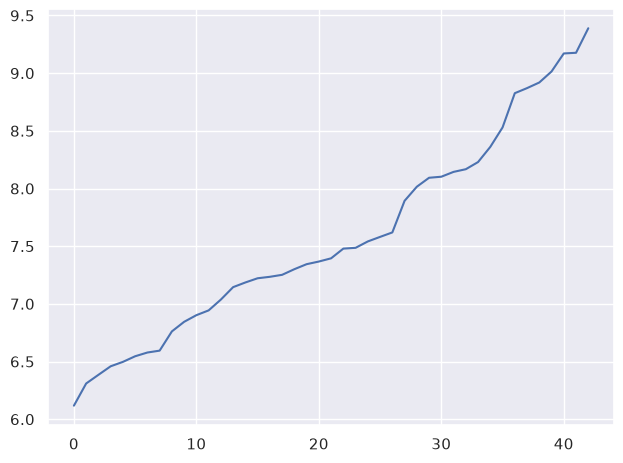

In [53]:
# Vamos a probar con 5 vecinos para el DBSCAN
n_dbscan = 5
vecinos_cercanos = NearestNeighbors(n_neighbors=n_dbscan+1).fit(df_selecciones_numerica_escalada) # +1 porque incluye a si mismo

# Ordenamos de menor a mayor las distancias y graficamos
distancias, _ = vecinos_cercanos.kneighbors(df_selecciones_numerica_escalada)
distancias = distancias[:,n_dbscan-1] # Tomamos la distancia al vecino más lejano (el n-ésimo vecino)
distancias = np.sort(distancias, axis=0)

# Graficamos la distancia al n-ésimo vecino más cercano para determinar el valor de eps
so.Plot(x = np.arange(len(distancias)), y = distancias).add(so.Line()).show()

# Utilizamos eps=8 y min_samples=n_dbscan+1 para el DBSCAN, ya que es un valor que nos permite separar los clusters de manera clara
dbscan = DBSCAN(eps=8, min_samples=n_dbscan+1)

# Separamos las selecciones en clusters
clusters_dbscan = dbscan.fit_predict(df_selecciones_numerica_escalada)

Ahora con KMeans

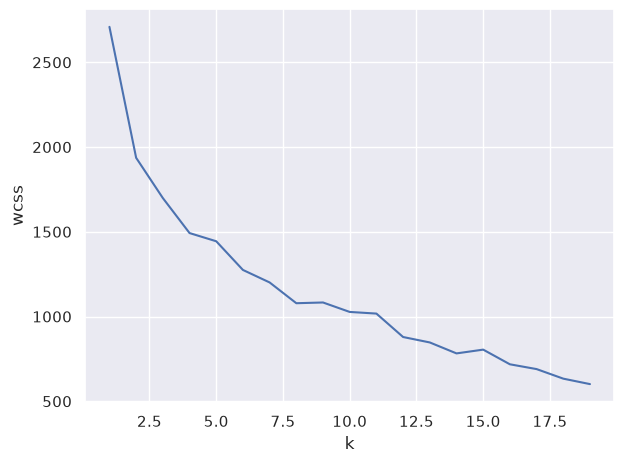

In [ ]:
# Vamos a guardar los errores de los distintos k
wcss = {}

# Pasamos a vector de numpy para poder calcular la distancia cuadrática al centroide
X = df_selecciones_numerica_escalada.to_numpy()

# Probamos con varios k, calculando el WCSS (Within-Cluster Sum of Squares) para cada uno
for k in range(1, 20, 1):
  # Creamos y entrenamos el modelo KMeans con k clusters
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(X)

  kmeans_wcss = 0

  # Por cada selección obtenemos el cluster al que pertenece y el centroide correspondiente, y calculamos la distancia cuadrática al centroide
  for i in range(len(X)):
    cluster = kmeans.labels_[i]
    centro = kmeans.cluster_centers_[cluster]

    kmeans_wcss += ((X[i] - centro) ** 2).sum()

  # Guardamos el WCSS para el k actual
  wcss[k] = kmeans_wcss

# Armamos un DataFrame con los resultados y graficamos el WCSS en función de k para determinar el valor óptimo de k
data = pd.DataFrame({
  "wcss": wcss
})
data.index.name = "k"
so.Plot(data=data, x="k", y="wcss").add(so.Line()).show()

# Utilizamos k=5 y separamos las selecciones en clusters
kmeans = KMeans(5)
clusters_kmeans = kmeans.fit_predict(df_selecciones_numerica_escalada)

## Ejercicio 4

Vamos a graficar de vuelta la Z2 en función de Z1 pero diferenciando a las selecciones con los clusters

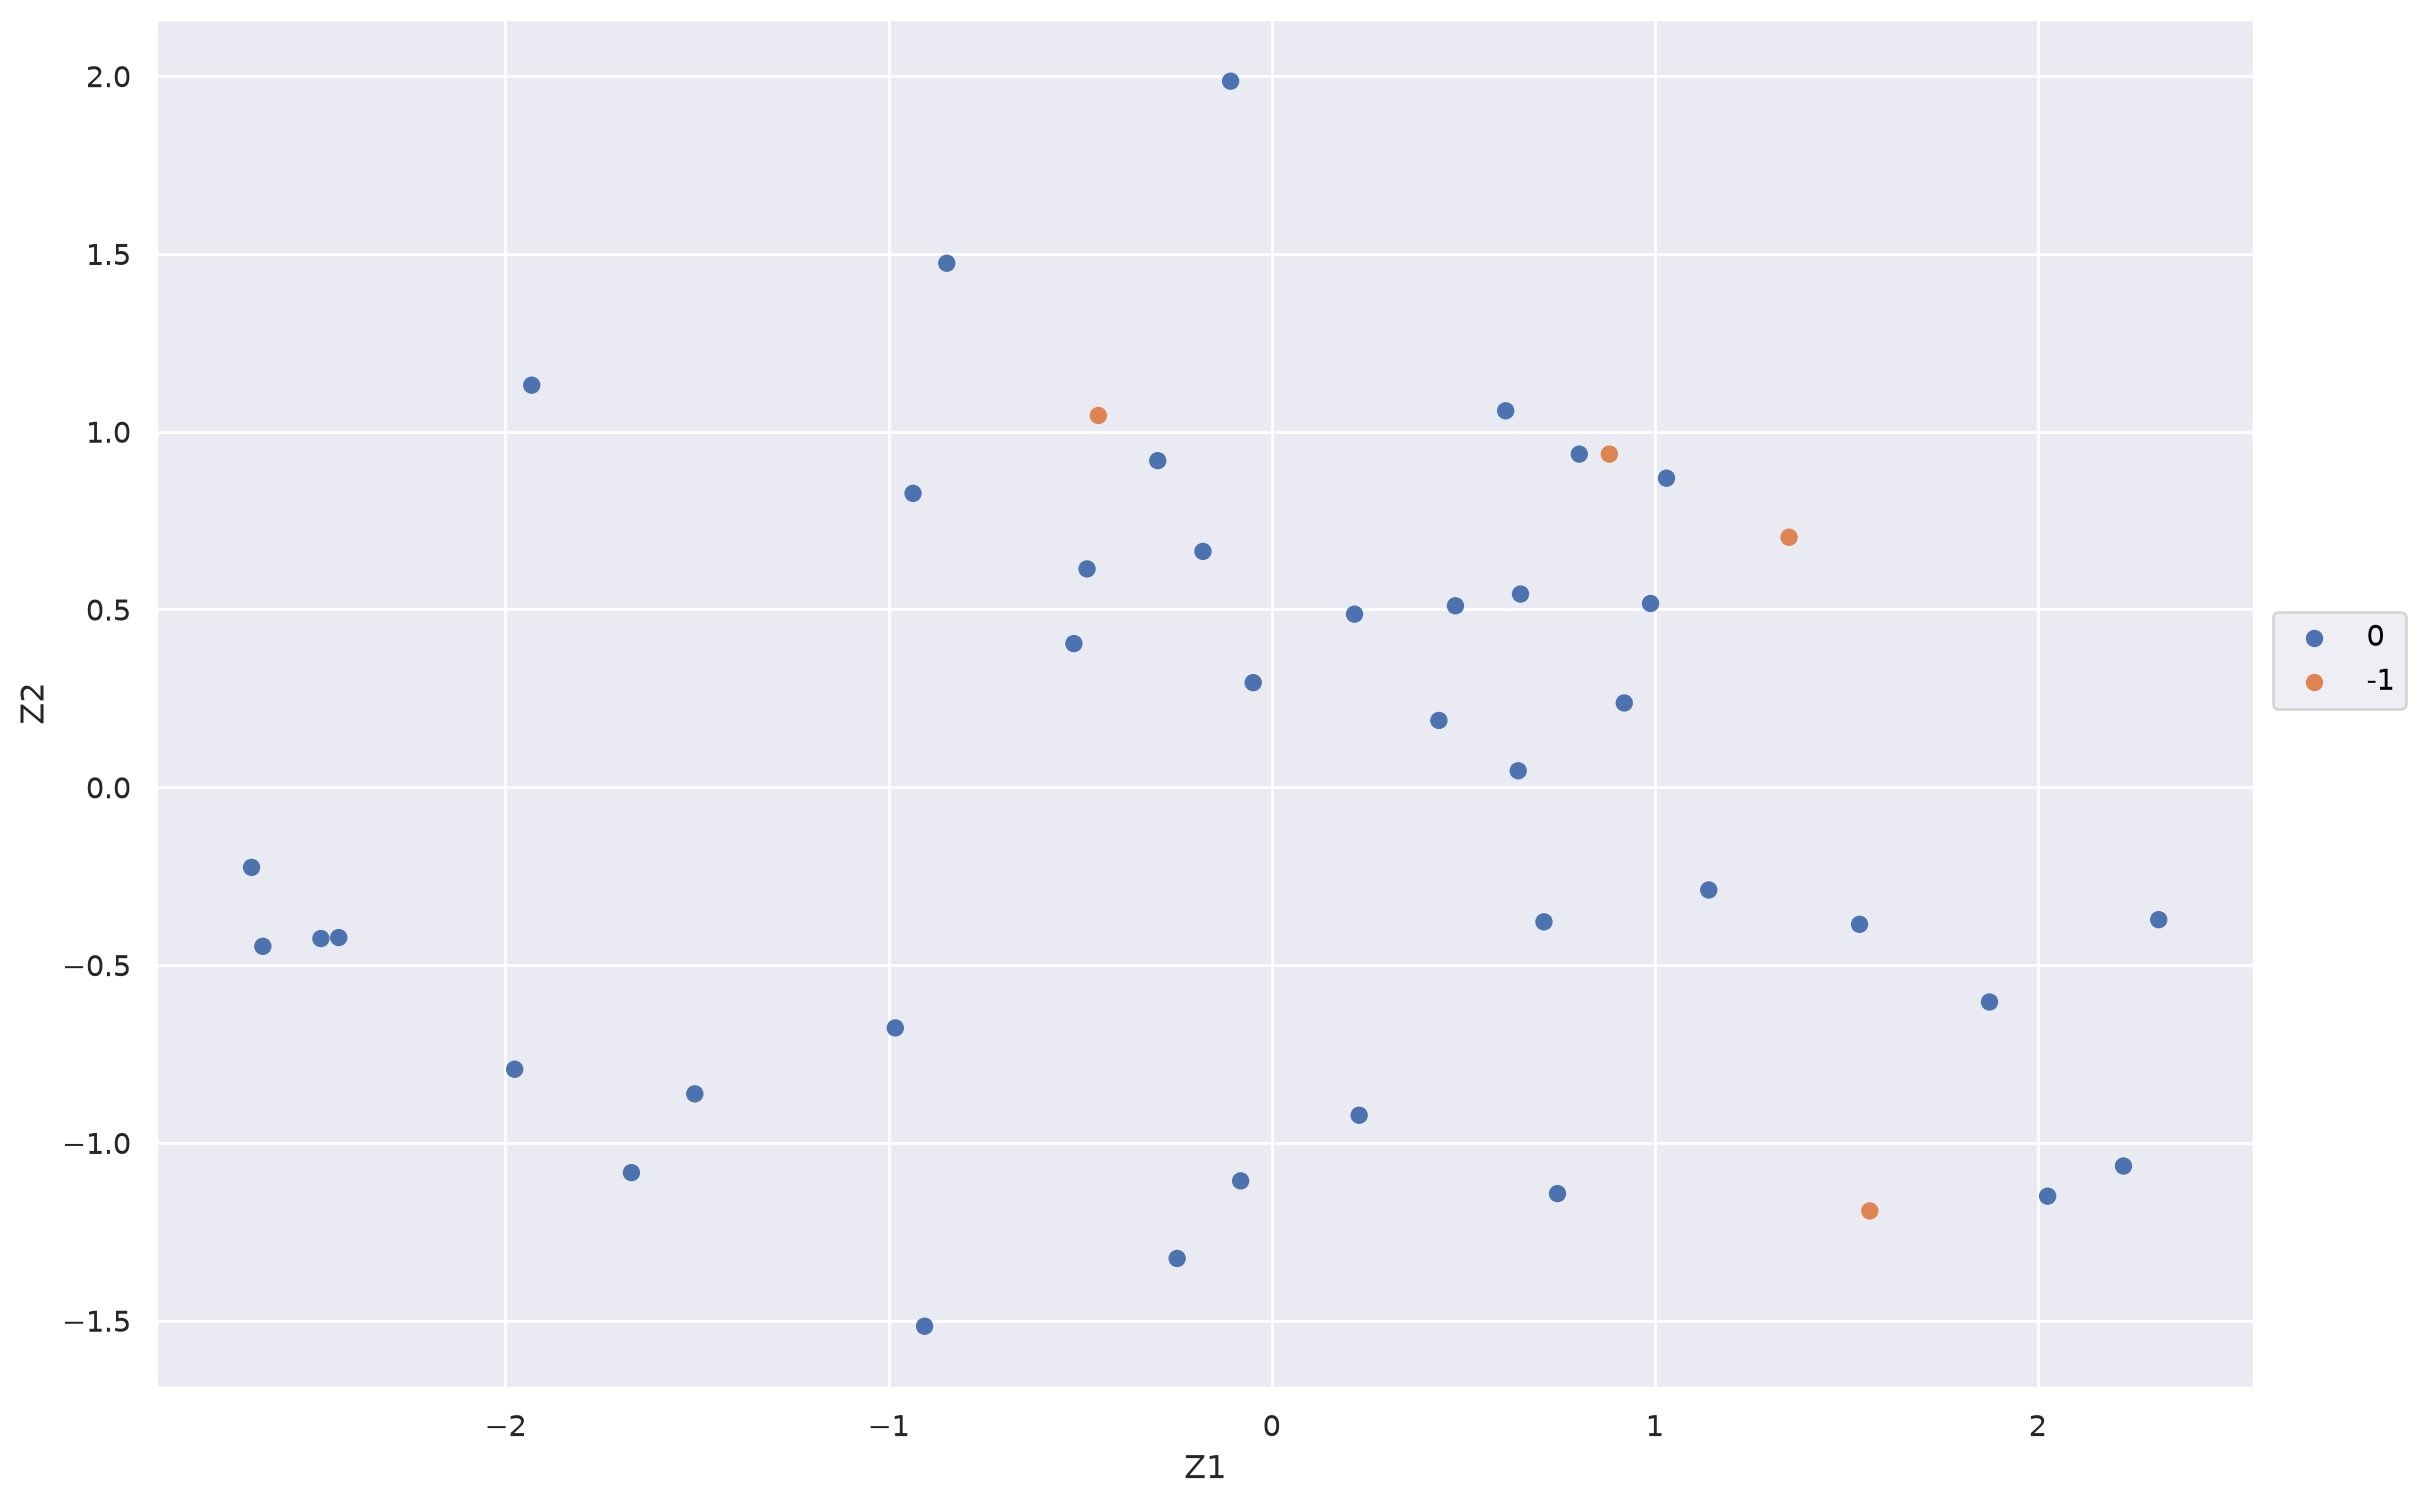

In [54]:
# Graficamos con los clusters obtenidos por DBSCAN
(
    so.Plot(data = Z, x="Z1", y="Z2", color=clusters_dbscan.astype(str))
    .add(so.Dot())
    .add(so.Text())
    .layout(size=(12,8))
)

Como se ve DBSCAN no logra agrupar de manera conveniente a las selecciones en clusters, ya que las mete prácticamente a todas juntas en uno mismo

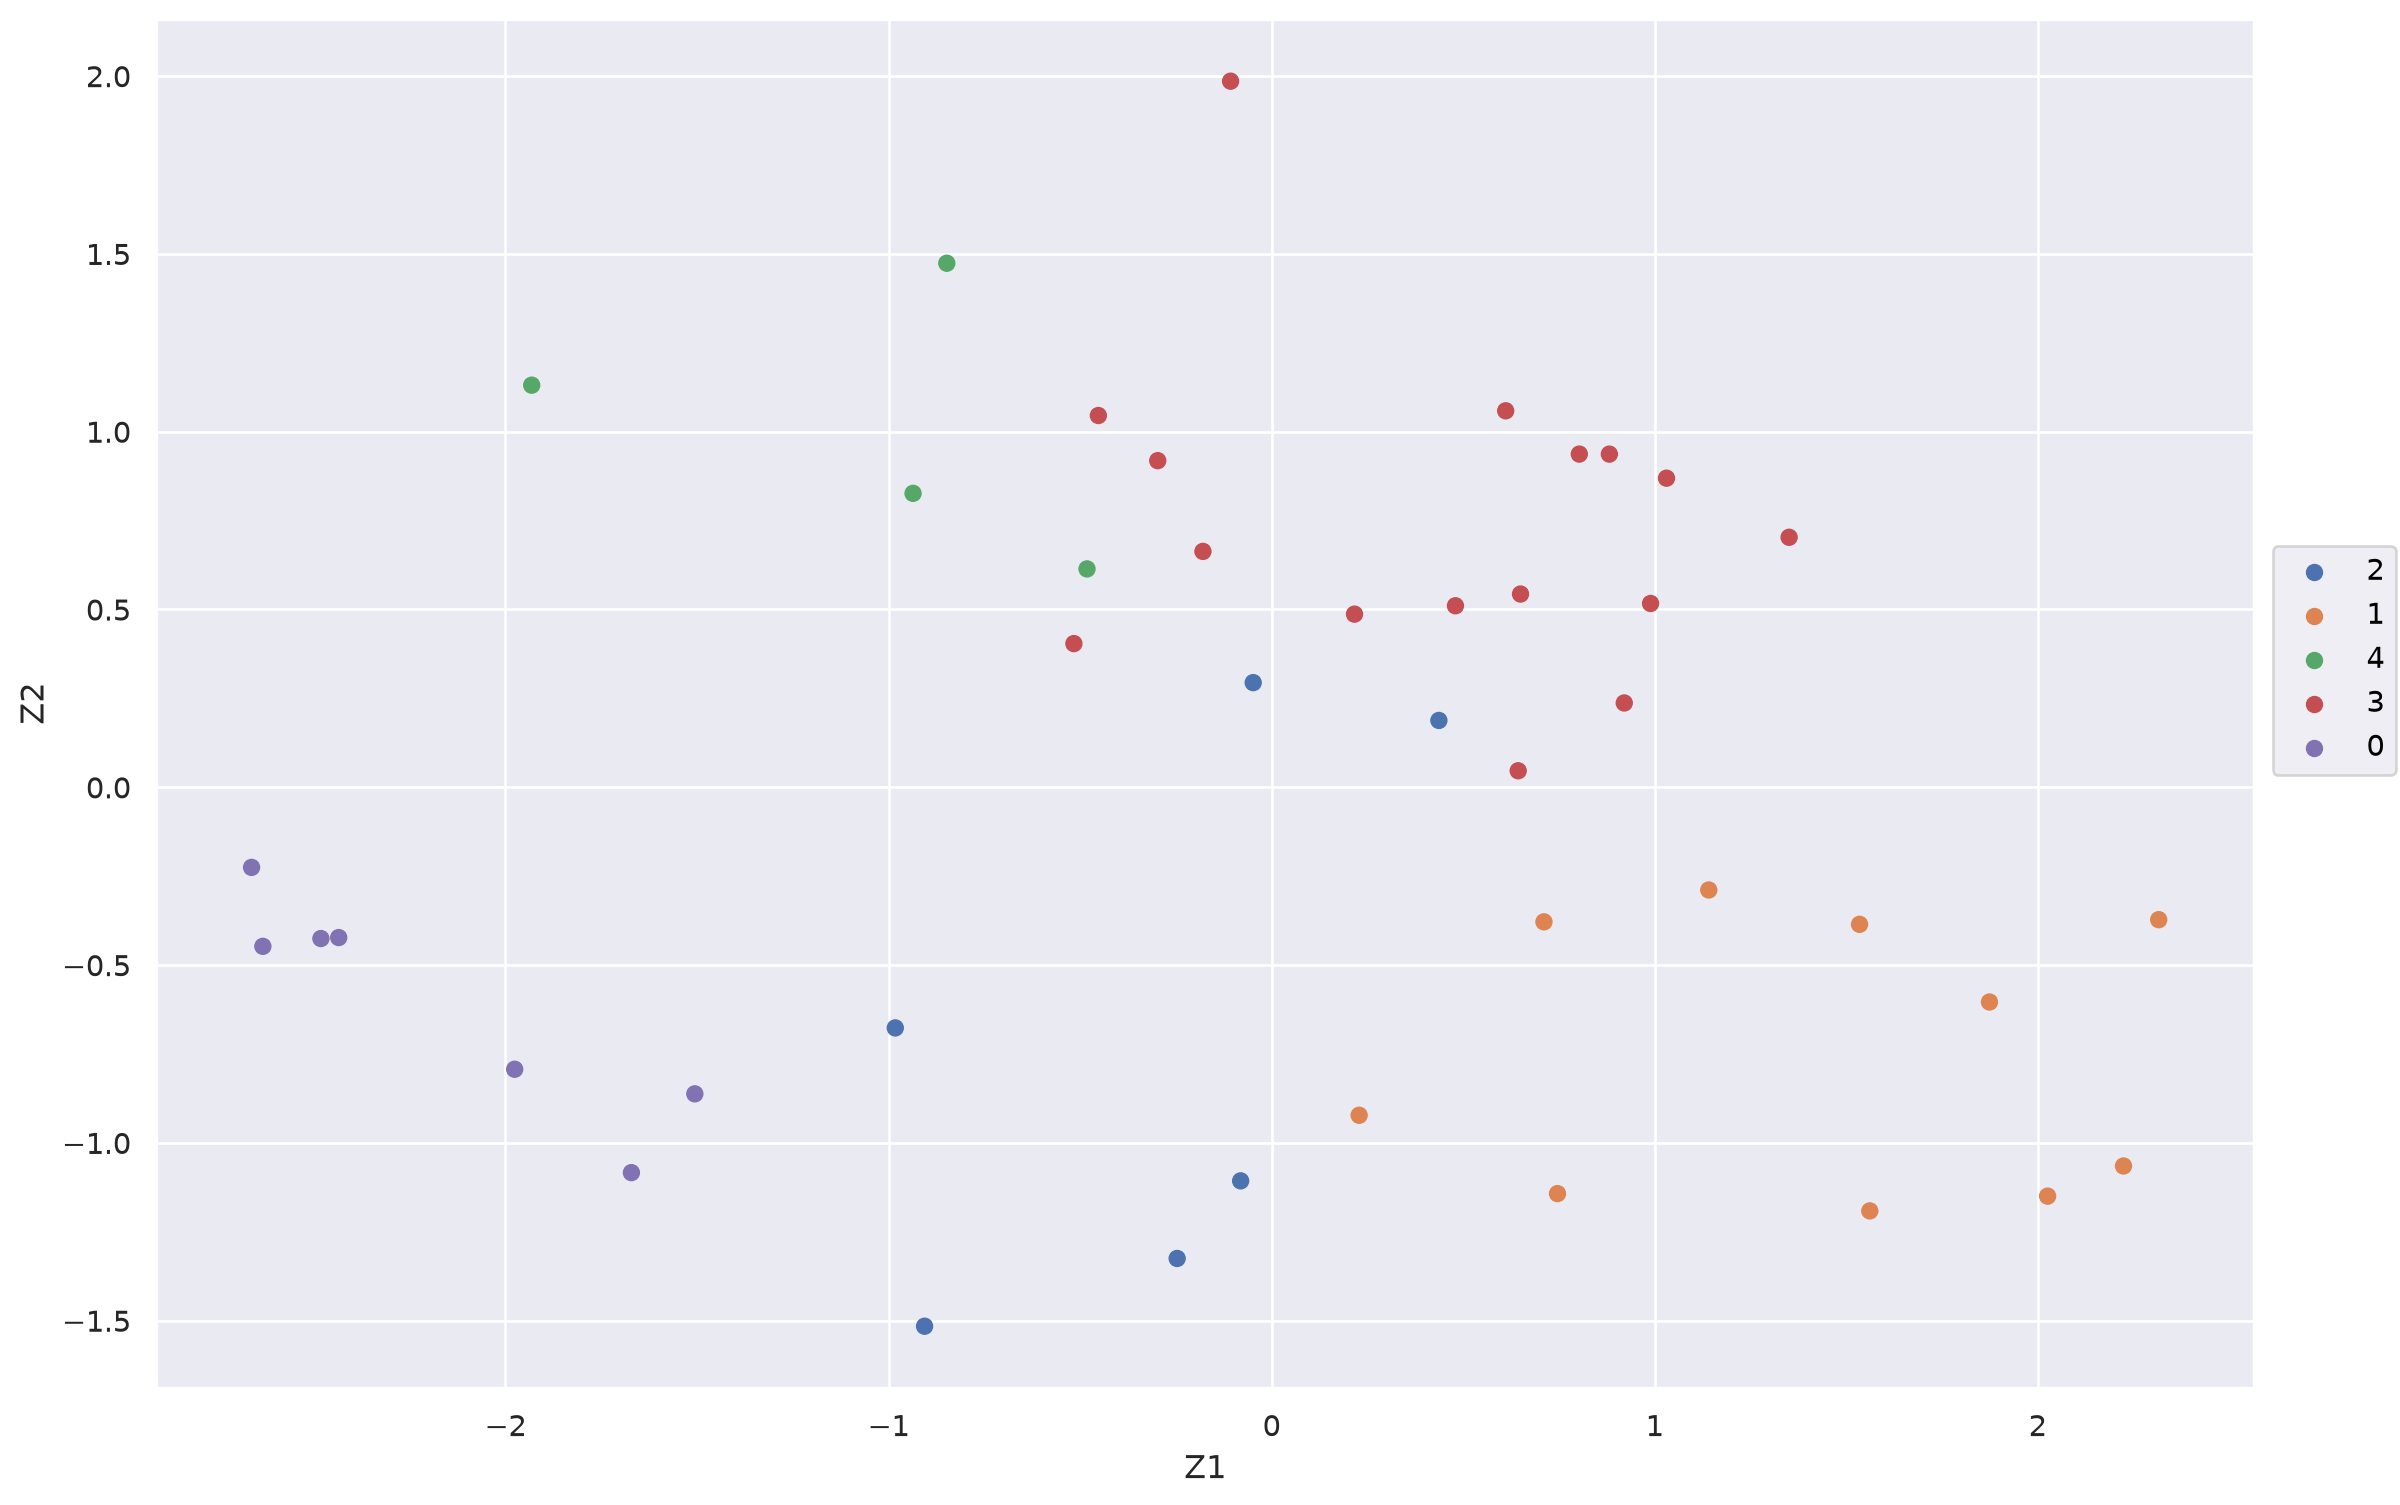

In [36]:
# Graficamos con los clusters obtenidos por KMeans
(
	so.Plot(data = Z, x="Z1", y="Z2", color=clusters_kmeans.astype(str))
    .add(so.Dot())
    .add(so.Text())
    .layout(size=(12,8))
)

Por otro lado, KMeans si consiguió dividirlas de una manera lógica en base a lo visto y analizado anteriormente

Calculemos la varianza total de las primeras dos componentes principales para determinar cuánta información logramos resumir con ellas

In [37]:
# Renombramos para mayor facilidad
X_star = df_selecciones_numerica_escalada

# Calculamos la matriz de covarianza:
# cov = (X - Xraya)^T * (X - Xraya) / N = (B^T * B) / N
X_star_t = np.transpose(X_star)
N = len(X_star)
Sigma = (X_star_t @ X_star) / N

# Calculamos los autovalores y autovectores de la matriz de covarianza, estos segundos los descartamos ya que no los vamos a utilizar
gamma, _ = np.linalg.eigh(Sigma)

# Reordenamos los autovalores de mayor a menor pues son los que se utilizan para PCA
gamma = np.flip(gamma)

# Calculamos la varianza explicada por cada componente principal y la varianza acumulada
for i in range(n_comps):
    print(f"Porcentaje de varianza explicada por la componente {i + 1}: {(gamma[i] / sum(gamma) * 100):.2f}%")

print(f"Porcentaje de varianza acumulada: {gamma[:n_comps].sum() / sum(gamma) * 100:.2f}%")

Porcentaje de varianza explicada por la componente 1: 41.14%
Porcentaje de varianza explicada por la componente 2: 14.98%
Porcentaje de varianza acumulada: 56.13%


Con las primeras dos componentes abarcamos la mitad de la varianza total. Inicialmente no es un número muy abarcativo, pero teniendo en cuenta la cantidad de información con la que trabajamos no es menor. Además, vimos que coinciden bien los clusters de KMeans con lo que estas dos primeras componentes nos muestran.

## Ejercicio 5

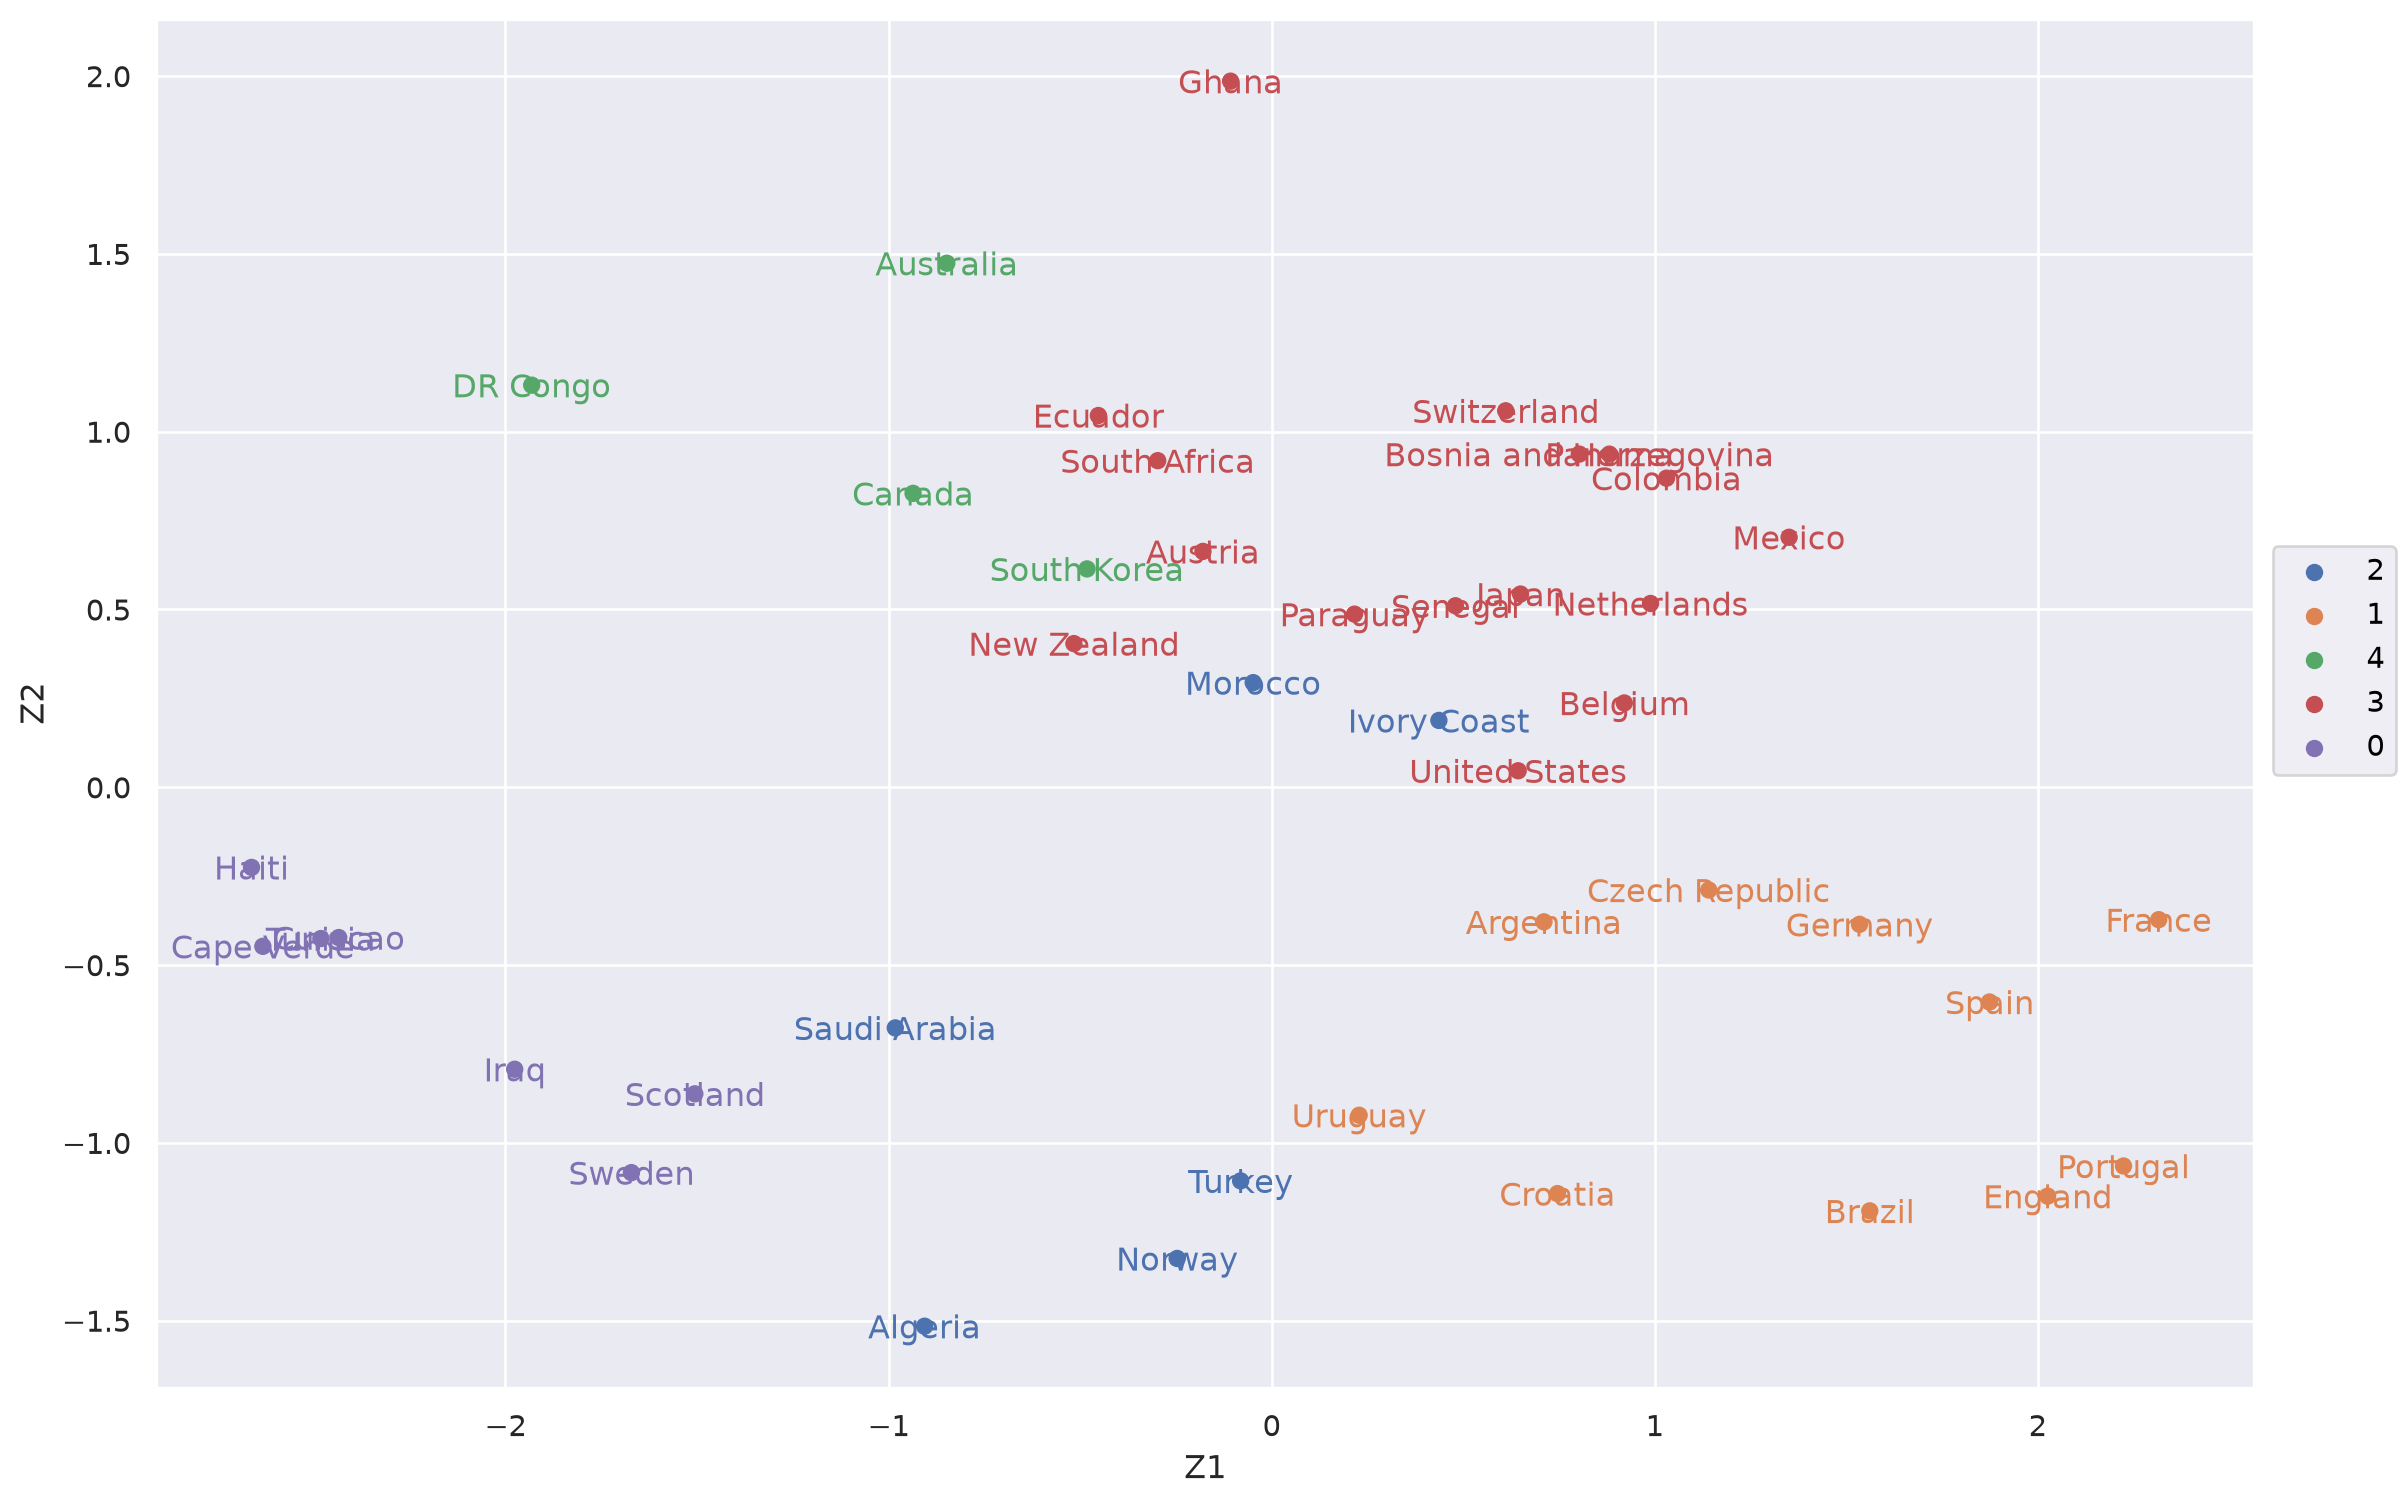

In [38]:
# Graficamos con los clusters obtenidos por KMeans
(
	so.Plot(data = Z, x="Z1", y="Z2", color=clusters_kmeans.astype(str), text=df_selecciones["seleccion"])
	.add(so.Dot())
	.add(so.Text())
	.layout(size=(12,8))
)

Podemos diferenciar varios tipos de selecciones con los clusters. Por ejemplo, si tomamos las del cluster inferior derecho (naranja), que tiene valores positivos en Z1 y negativos en Z2, notamos que son selecciones de muy alto nivel, donde probablemente los arqueros tengan mejor rendimiento y los jugadores generen más oportunidades de tiro y goles.

# Regresión y clasificación

## Ejercicio 1

Vamos a crear un nuevo DataFrame agregando la variable "patidos_liga", que indica en cada jugador qué porcentaje de los partidos de su liga jugó

In [39]:
# Hacemos una copia de df_jugadores_limpia
df_jugadores_regresion = df_jugadores_limpia.copy()

# Estimamos los partidos de cada liga con el máximo de partidos jugados por sus jugadores
max_partidos = df_jugadores_regresion.groupby("confederacion")["standard_playing_time_mp"].max()

# Creamos "partidos_liga" dividiendo la cantidad de minutos jugados por el jugador por la cantidad de partidos de su liga y 90
df_jugadores_regresion["partidos_liga"] = [jugador["standard_playing_time_min"]/(max_partidos[jugador["confederacion"]]*90) for _, jugador in df_jugadores_regresion.iterrows()]
df_jugadores_regresion.head()

,player_id,seleccion,numero,posicion,jugador,fecha_nac,edad,caps,goles_seleccion,club,...,keeper_performance_cspct,keeper_penalty_kicks_pkatt,keeper_penalty_kicks_pka,keeper_penalty_kicks_pksv,keeper_penalty_kicks_pkm,keeper_penalty_kicks_savepct,keeper_playing_time_90s,valor_mercado_eur,rango_etario,partidos_liga
0,1,Czech Republic,1,GK,Matěj Kovář,2000-05-17,26,19,0,PSV Eindhoven,...,22.6,4.0,3.0,0.0,1.0,0.0,31.0,7000000.0,B,0.794872
1,2,Czech Republic,2,DF,David Zima,2000-11-08,25,24,1,Slavia Prague,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4500000.0,B,0.529060
2,3,Czech Republic,3,DF,Tomáš Holeš,1993-03-31,33,40,2,Slavia Prague,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2200000.0,C,0.596296
3,4,Czech Republic,4,DF,Robin Hranáč,2000-01-29,26,13,1,TSG Hoffenheim,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5500000.0,B,0.641311
4,5,Czech Republic,5,DF,Vladimír Coufal,1992-08-22,33,61,2,TSG Hoffenheim,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7000000.0,C,0.858120


## Ejercicio 2

Para elegir el mejor modelo de regresión vamos a probar con un modelo lineal Multivariado y un modelo lineal Ridge

In [40]:
# Creamos nuestras matrices de datos eliminando toda variable que tenga que ver con cantidad de partidos y minutos jugados
y = df_jugadores_regresion["partidos_liga"]
X = df_jugadores_regresion.select_dtypes(include='number').drop(columns=["player_id", "numero", "partidos_liga", "caps", "standard_playing_time_mp", "standard_playing_time_starts", "standard_playing_time_min", "standard_playing_time_90s", "shooting_90s", "misc_90s"])
scaler = StandardScaler().set_output(transform="pandas")

# Separamos los datos en entrenamiento y prueba, y escalamos las variables
test_split = 0.3
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_split, random_state=random_state)
# scaler = MinMaxScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Creamos una función auxiliar para facilitar la evaluación del modelo

In [41]:
def evaluacion_modelo_final(modelo, X_train, y_train, X_test, y_test):
	# Ajustamos nuestro modelo ganador en TODO el conjunto de entrenamiento.
	modelo.fit(X_train, y_train)

	# Predicciones
	y_pred = modelo.predict(X_test)

	# Bondad del ajuste
	r2 = r2_score(y_test, y_pred)
	print('R^2: ', r2)
	recm = root_mean_squared_error(y_test, y_pred)
	print('Raiz cuadrada del ECM: ', recm)

Primero veamos el rendimiento del modelo lineal Multivariado

In [42]:
# Creamos el modelo con intercept ya que nuestra matriz no tiene columna de 1s
modelo = LinearRegression(fit_intercept=True)

evaluacion_modelo_final(modelo, X_train, y_train, X_test, y_test)

R^2:  0.8370758137416372
Raiz cuadrada del ECM:  0.0910022818968055


El modelo lineal Multivariado tuvo un gran resultado con R^2 = 0,83. Veamos como resulta el modelo Ridge.

Para elegir el óptimo alfa del modelo Ridge vamos a usar el esquema de validación cruzada con 5 pliegues

In [43]:
# Probamos con alfa entre 1 y 40, y 5 pliegues de validación cruzada
alfas = [i for i in range(1, 40)]
splits = 5

# Vamos a guardar los errores de entrenamiento de los distintos alfas
rmse_train_mean = {}
intercepts = {}

# Para cada alfa, creamos un modelo Ridge y hacemos validación cruzada
# Luego, guardamos el error de entrenamiento promedio en rmse_train
for alfa in alfas:
	cv = KFold(n_splits=splits, random_state=random_state, shuffle=True)
	ridge = Ridge(alpha=alfa)
	rmse_train = np.zeros(cv.get_n_splits())
	ind = 0

	# En cada pliegue entrenamos el modelo y calculamos el RMSE en el conjunto de validación
	for train_index, val_index in cv.split(X_train):
		X_train2, X_val, y_train2, y_val = X_train.iloc[train_index], X_train.iloc[val_index], y_train.iloc[train_index], y_train.iloc[val_index]
		ridge.fit(X_train2, y_train2)
		rmse_train[ind] = root_mean_squared_error(y_val, ridge.predict(X_val))
		ind += 1

	# Guardamos el promedio de errores para el alfa actual
	rmse_train_mean[alfa] =  rmse_train.mean()
	intercepts[alfa] = ridge.intercept_

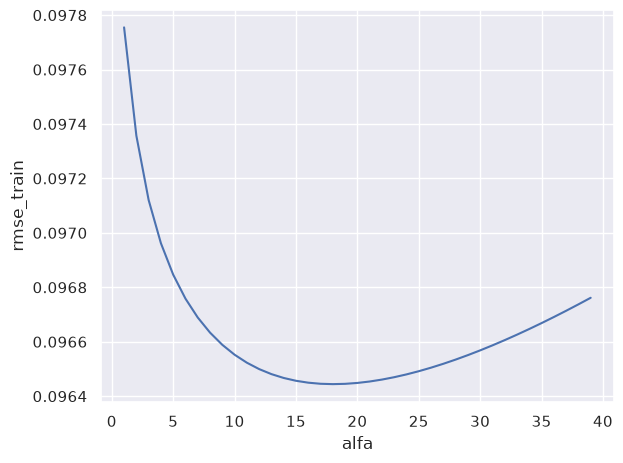

El valor de alfa que minimiza el RMSE en train es:  18
R^2:  0.8384211822251606
Raiz cuadrada del ECM:  0.09062577119371207


In [44]:
# Convertimos a DataFrame para graficar
data = pd.DataFrame(
    {
        "rmse_train": rmse_train_mean,
    }
).reset_index(names="alfa")

# Graficamos los residuos en función de alfa
(
    so.Plot(data = data, x= "alfa")
    .add(so.Line(), y = "rmse_train")
	.show()
)

# Nos quedamos con el alfa que minimiza el RMSE en train
alpha = data["alfa"][(data["rmse_train"]).idxmin()]
print("El valor de alfa que minimiza el RMSE en train es: ", alpha)

# Creamos el modelo final con el alfa óptimo y evaluamos su desempeño en el conjunto de test
ridge = Ridge(alpha=alpha)
evaluacion_modelo_final(ridge, X_train, y_train, X_test, y_test)
predicciones_tiempo = ridge.predict(X)

Aunque no es por mucha diferencia, el modelo lineal Ridge tuvo un mejor desempeño que el Multivariado, así que nos quedamos con este para la última parte

## Ejercicio 3

Para elegir el K óptimo vamos a hacer validación cruzada Leave-One-Out, donde predecimos la posición de cada jugador en base a las distancias del todo el resto

In [45]:
# Función que predice la posición de un jugador a partir de las de sus vecinos más cercanos
def predecir(jugadores, posiciones, ind, modelo):

    # Eliminamos al propio jugador, para no incluirlo en los vecinos
    jugadores2 = jugadores.drop(index=ind)
    posiciones2 = posiciones.drop(index=ind)

    # Entrenamos el modelo con los jugadores restantes
    modelo.fit(jugadores2)

    # Obtenemos la posición de los K vecinos más cercanos
    _, indices = modelo.kneighbors(jugadores.iloc[[ind]])
    votos = posiciones2.iloc[indices.flatten()]

    # Devolvemos la posición más votada por los vecinos
    return(mode(votos))

def knn_leave_one_out(jugadores, posiciones, K):
    correctos = 0
    total = len(jugadores)

    # Usamos NearestNeighbors para encontrar los K vecinos más cercanos de cada jugador
    vecinos_mas_cercanos = NearestNeighbors(n_neighbors=K)

    # Por cada jugador, predecimos su posición a partir de las posiciones de sus K vecinos más cercanos y comparamos con la posición real
    for i in range(total):
        prediccion = predecir(jugadores, posiciones, i, vecinos_mas_cercanos)
        if(prediccion == posiciones.iloc[i]):
            correctos += 1

    # Devolvemos la accuracy o precisión del modelo, es decir, la cantidad de predicciones correctas sobre el total de predicciones.
    return(correctos/total)

In [46]:
# Armamos nuestras matrices de datos y escalamos
y = df_jugadores_limpia["posicion"]
X = df_jugadores_limpia.select_dtypes(include='number').drop(columns=["player_id", "numero"])
scaler = StandardScaler().set_output(transform="pandas")
X_scaled = scaler.fit_transform(X)

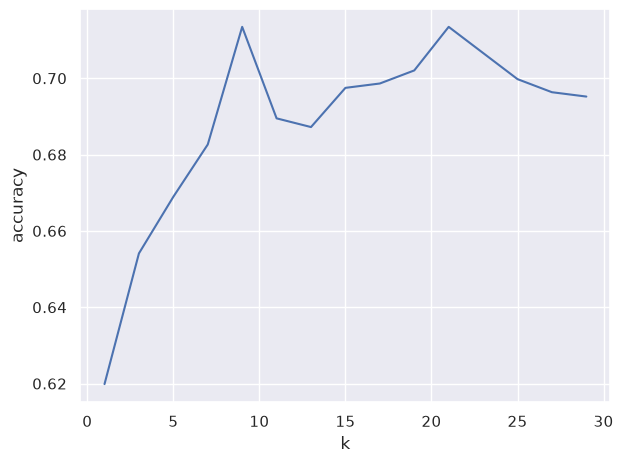

El valor de k que maximiza los aciertos es: 9, con 0.7134703196347032 porcentaje de precision


In [47]:
# Probamos con K impares entre 1 y 29, y guardamos la accuracy de cada uno
aciertos = {}

for K in range(1,30,2):
	aciertos[K] = knn_leave_one_out(X_scaled, y, K)

aciertos = pd.DataFrame({
	"k": aciertos.keys(),
	"accuracy": aciertos.values()
})

(
	so.Plot(data = aciertos, x="k", y="accuracy")
	.add(so.Line())
	.show()
)

# Buscamos el valor de k que maximiza la accuracy
ind_max = aciertos["accuracy"].idxmax()
k = aciertos["k"][ind_max]
print(f"El valor de k que maximiza los aciertos es: {k}, con {aciertos['accuracy'][ind_max]} porcentaje de precision")

Una vez conseguido el k óptimo volvemos a predecir las posiciones según los k vecinos mas cercanos y las guardamos

In [48]:
modelo_posiciones = NearestNeighbors(n_neighbors=k)
clasificacion_posiciones = []

for ind in range(len(X_scaled)):
	prediccion = predecir(X_scaled, y, ind, modelo_posiciones)
	clasificacion_posiciones.append(prediccion)

# El 11 ideal de Argentina y Brasil

Añadimos al DataFrame las columnas "minutos_pred" y "posicion_pred" que tienen las predicciones del ejercicio anterior

In [49]:
df_jugadores_limpia["minutos_pred"] = predicciones_tiempo
df_jugadores_limpia["posicion_pred"] = clasificacion_posiciones

Ahora sí, ordenamos a los jugadores de las selecciones de Argentina y Brasil según su posición y el tiempo estimado de juego, según nuestros modelos

In [50]:
def mejores_jugadores(seleccion, posicion, cantidad):
	jugadores = df_jugadores_limpia[(df_jugadores_limpia["seleccion"] == seleccion) & (df_jugadores_limpia["posicion_pred"] == posicion)]
	indices = jugadores["minutos_pred"].sort_values(ascending=False).head(cantidad).index
	return df_jugadores_limpia.loc[indices]["jugador"].to_list()

arquero_arg = mejores_jugadores("Argentina", "GK", 1)
defensores_arg = mejores_jugadores("Argentina", "DF", 4)
mediocampistas_arg = mejores_jugadores("Argentina", "MF", 4)
delanteros_arg = mejores_jugadores("Argentina", "FW", 2)

arquero_bra = mejores_jugadores("Brazil", "GK", 1)
defensores_bra = mejores_jugadores("Brazil", "DF", 4)
mediocampistas_bra = mejores_jugadores("Brazil", "MF", 4)
delanteros_bra = mejores_jugadores("Brazil", "FW", 2)

Finalmente, comparamos las selecciones obtenidas con las titularesd de Argentina y Brasil en sus primeros partidos

In [51]:
titulares = [
	"Emiliano Martínez", # Arquero

	# Defensores
	"Cristian Romero",
	"Facundo Medina",
	"Gonzalo Montiel",
	"Lisandro Martínez",

	# Mediocampistas
	"Alexis Mac Allister",
	"Enzo Fernández",
	"Rodrigo De Paul",
	"Thiago Almada",

	# Delanteros
	"Lautaro Martínez",
	"Lionel Messi"
]

defensores_arg.sort()
mediocampistas_arg.sort()
delanteros_arg.sort()

once_arg = pd.DataFrame({
	"Posición": ["Arquero"] + ["Defensor"]*4 + ["Mediocampista"]*4 + ["Delantero"]*2,
	"Once ideal": arquero_arg + defensores_arg + mediocampistas_arg + delanteros_arg,
	"Once titular vs Argelia": titulares
})
once_arg

,Posición,Once ideal,Once titular vs Argelia
0,Arquero,Emiliano Martínez,Emiliano Martínez
1,Defensor,Alexis Mac Allister,Cristian Romero
2,Defensor,Cristian Romero,Facundo Medina
3,Defensor,Exequiel Palacios,Gonzalo Montiel
4,Defensor,Lisandro Martínez,Lisandro Martínez
5,Mediocampista,Enzo Fernández,Alexis Mac Allister
6,Mediocampista,Giovani Lo Celso,Enzo Fernández
7,Mediocampista,Giuliano Simeone,Rodrigo De Paul
8,Mediocampista,Nicolás Tagliafico,Thiago Almada
9,Delantero,Julián Alvarez,Lautaro Martínez


In [52]:
titulares = [
    "Alisson",  # Arquero

    # Defensores
    "Douglas Santos",
    "Gabriel Magalhães",
    "Ibañez",
    "Marquinhos",

    # Mediocampistas
    "Bruno Guimarães",
    "Casemiro",

    # Delanteros
    "Lucas Paquetá",
    "Raphinha",
    "Thiago",
    "Vinícius Júnior"
]

defensores_bra.sort()
mediocampistas_bra.sort()
delanteros_bra.sort()

once_bra = pd.DataFrame({
	"Posición": ["Arquero"] + ["Defensor"]*4 + ["Mediocampista"]*4 + ["Delantero"]*2,
	"Once ideal": arquero_bra + defensores_bra + mediocampistas_bra + delanteros_bra,
	"Once titular vs Marruecos": titulares
})
once_bra

,Posición,Once ideal,Once titular vs Marruecos
0,Arquero,Ederson,Alisson
1,Defensor,Fabinho,Douglas Santos
2,Defensor,Léo Pereira,Gabriel Magalhães
3,Defensor,Marquinhos,Ibañez
4,Defensor,Roger Ibañez,Marquinhos
5,Mediocampista,Bruno Guimarães,Bruno Guimarães
6,Mediocampista,Gabriel Magalhães,Casemiro
7,Mediocampista,Lucas Paquetá,Lucas Paquetá
8,Mediocampista,Matheus Cunha,Raphinha
9,Delantero,Raphinha,Thiago


# Conclusión